# Colorectal Cancer Tissue Classification with Deep Learning

This project explores several deep learning approaches for multiclass classification of colorectal cancer histology images from the PathMNIST dataset. We progressively compare increasingly complex architectures, starting from a dense neural network baseline, then moving to a convolutional neural network, transfer learning with ResNet-18, and finally a Vision Transformer. The objective is not only to obtain strong predictive performance, but also to understand the strengths, limitations, and interpretability of each method.

## Project overview

The goal of this project is to classify colorectal cancer histology patches into 9 tissue classes using the PathMNIST dataset. This dataset contains RGB images of size 28×28 extracted from histopathology slides. Since tissue classification is an important step in computational pathology, this task has both methodological and clinical relevance. In this notebook, we follow the progression requested in the project instructions, from a simple dense baseline to more advanced architectures such as convolutional networks, pretrained ResNet, and Vision Transformers. We also include an interpretability analysis using Grad-CAM in order to better understand which regions of the images drive the model predictions.

## Data and library importation

We begin by importing the required Python libraries for dataset handling, visualization, preprocessing, model training, and evaluation. The PathMNIST dataset is provided through the `medmnist` library, which offers a convenient way to access the train, validation, and test splits. At this stage, the goal is simply to prepare the environment and verify that all required tools are available before starting the analysis.

In [1]:
!pip install medmnist
from medmnist import PathMNIST

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.7 MB/s eta 0:00:00


## 1. Data Exploration

Before training any model, it is essential to understand the structure and visual content of the dataset. In this section, we inspect the PathMNIST images, verify their dimensions, identify the class labels, and visualize representative samples from each tissue category. This preliminary exploration helps us better understand the classification problem and provides intuition about which classes may be visually easy or difficult to distinguish.

In [2]:
from medmnist import INFO
data_flag = "pathmnist"
info = INFO[data_flag]

print(info)

{'python_class': 'PathMNIST', 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.', 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1', 'MD5': 'a8b06965200029087d5bd730944a56c1', 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1', 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616', 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1', 'MD5_128': 

The PathMNIST dataset is already organized into training, validation, and test subsets. We load each split separately in order to respect a proper experimental protocol: the training set is used to optimize the model parameters, the validation set is used for model selection and hyperparameter tuning, and the test set is reserved for the final evaluation only.

In [3]:
train = PathMNIST(split="train", download=True)
val = PathMNIST(split="val", download=True)
test = PathMNIST(split="test", download=True)

# extract the images and labels from the datasets
train_images = train.imgs
train_labels = train.labels
val_images = val.imgs
val_labels = val.labels
test_images = test.imgs
test_labels = test.labels

100%|██████████| 206M/206M [00:13<00:00, 15.4MB/s] 


We now inspect the dataset structure in more detail. In particular, we verify the image dimensions, the number of classes, and the label encoding. Since PathMNIST is a multiclass histology classification task with 9 tissue categories, understanding this structure is necessary before defining any neural network architecture.

In [7]:
# get image shape
train_images.shape

(89996, 28, 28, 3)

To better understand the visual diversity of the dataset, we display one representative image for each class. This first qualitative overview allows us to observe differences in color, texture, and tissue organization across categories such as adipose tissue, debris, lymphocytes, normal mucosa, and tumor epithelium. We have 9 classes '0' adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'

/tmp/ipykernel_55/854996401.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


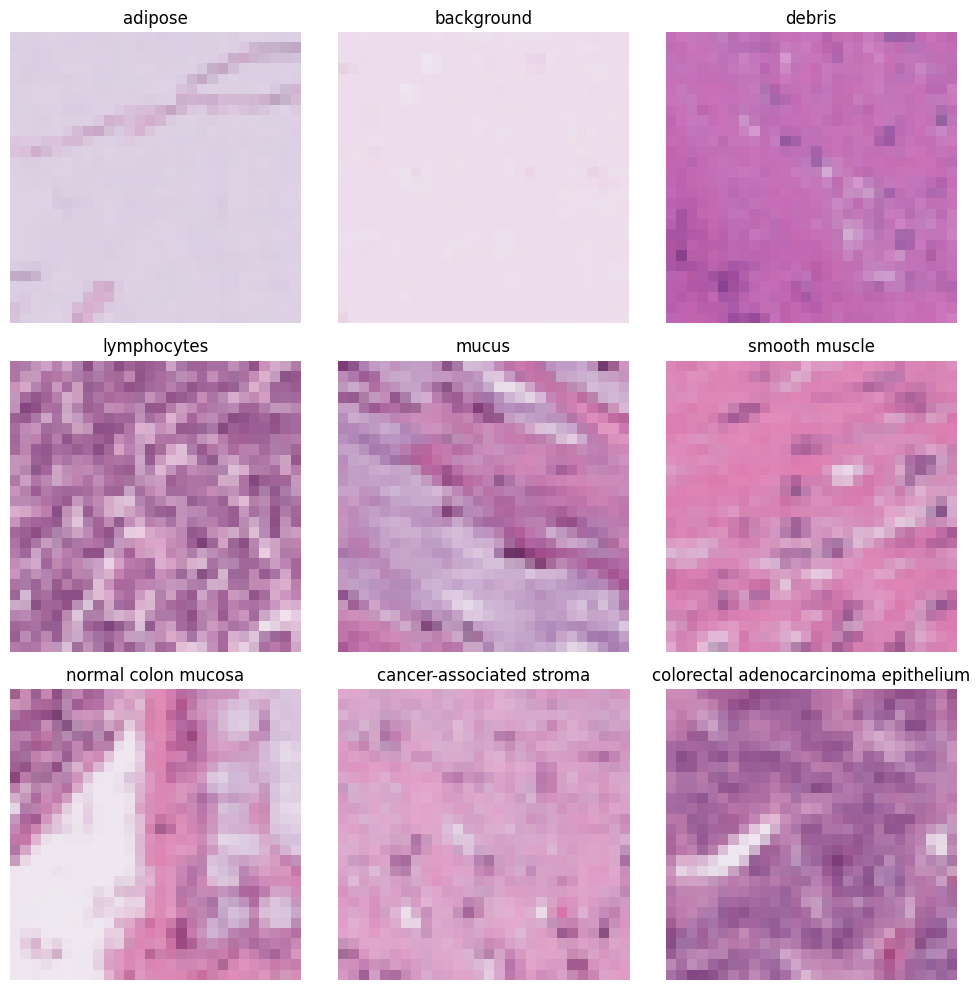

In [8]:

# Display one image per class
import matplotlib.pyplot as plt

num_classes = 9
class_images = [None] * num_classes
# find one image per class
for img, label in zip(train_images, train_labels):
    label = int(label)
    if class_images[label] is None:
        class_images[label] = img
    if all(x is not None for x in class_images):
        break

labels_names = info["label"]

# plot the images
plt.figure(figsize=(10,10))

for i in range(num_classes):
    plt.subplot(3,3,i+1)
    plt.imshow(class_images[i])
    plt.title(labels_names.get(str(i)))
    plt.axis("off")

plt.tight_layout()
plt.show()

The project instructions specifically ask us to compare the Debris and Background classes. This comparison is useful because some tissue categories may appear visually subtle at low resolution. By displaying several examples from both classes, we can identify characteristic differences in texture, color distribution, and structural organization.

/tmp/ipykernel_55/3835005171.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


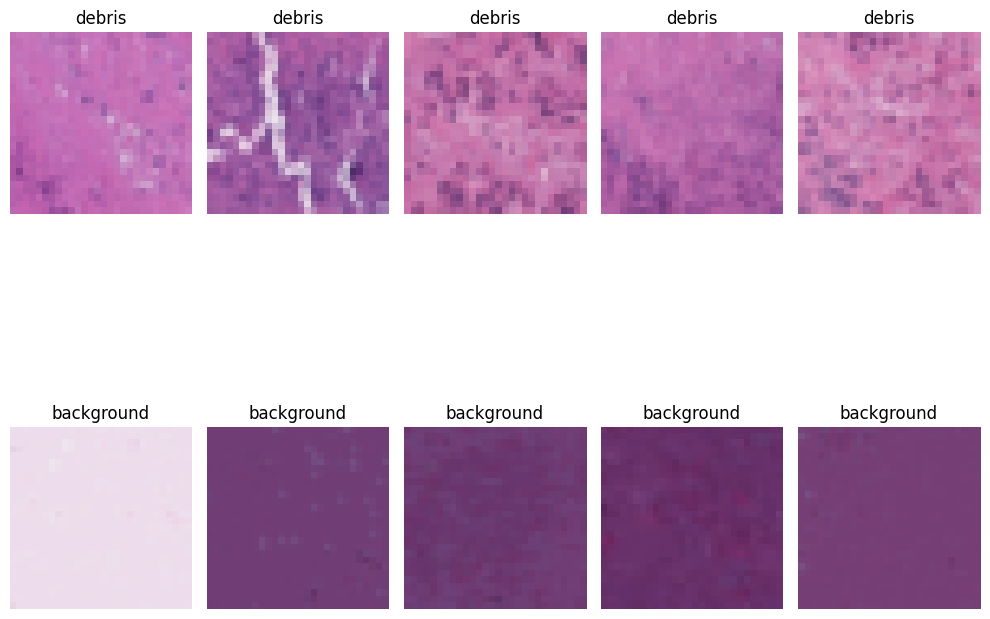

In [9]:
# look several images of the class "debris" and the class "background"
debris_images = []
background_images = []
i=0
j=0
for img, label in zip(train_images, train_labels):
    label = int(label)
    if label == 2:
        debris_images.append(img)
        i += 1
    elif label == 1:
        background_images.append(img)
        j += 1
    if i == 5 and j == 5:
        break
# plot the images
plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(debris_images[i])
    plt.title("debris")
    plt.axis("off")
for i in range(5):
    plt.subplot(2, 5, i+6)
    plt.imshow(background_images[i])
    plt.title("background")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Q1.1 – Visual comparison between Debris and Background

The Debris images tend to show more heterogeneous and irregular patterns than the Background images. In many debris samples, we can observe fragmented textures, denser local structures, and stronger color variation, often with darker purple or pink regions distributed unevenly across the patch. In contrast, the Background class generally appears more uniform, smoother, and visually emptier, with less structural content and weaker texture. Another noticeable difference is that debris often contains small clustered elements or tissue remnants, whereas background patches contain larger homogeneous areas with fewer meaningful visual details. Overall, debris seems more complex and textured, while background appears flatter and less informative.

To complement the visual exploration, we compute simple pixel statistics on one image from the training set. More precisely, we measure the mean and standard deviation for each RGB channel. These values help us quantify the image intensity distribution and allow us to compare it with commonly used normalization statistics such as those of ImageNet.

6


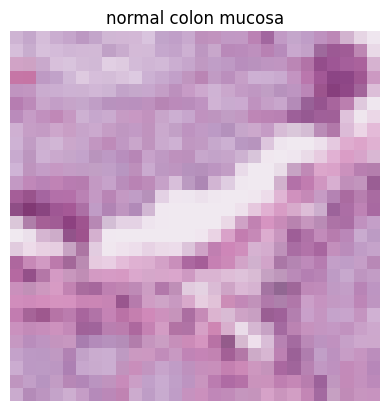

In [10]:
# pick any image from training dataset display it
import numpy as np
#pick an image
random_number = np.random.randint(0, len(train_images))
image_rdm = train_images[random_number]
label_rdm = train_labels[random_number]
print(label_rdm[0])
# display the image
plt.imshow(image_rdm)
plt.axis("off")
plt.title(labels_names.get(str(label_rdm[0])))
plt.show()

In [11]:
# report the pixel intensity statistics: mean and standard deviation per channel
means = np.mean(image_rdm, axis=(0,1))
stds = np.std(image_rdm, axis=(0,1))
print("Mean per channel:", means)
print("Standard deviation per channel:", stds)

Mean per channel: [197.54209184 154.95153061 194.12372449]
Standard deviation per channel: [20.3833982  34.13475244 22.41523144]


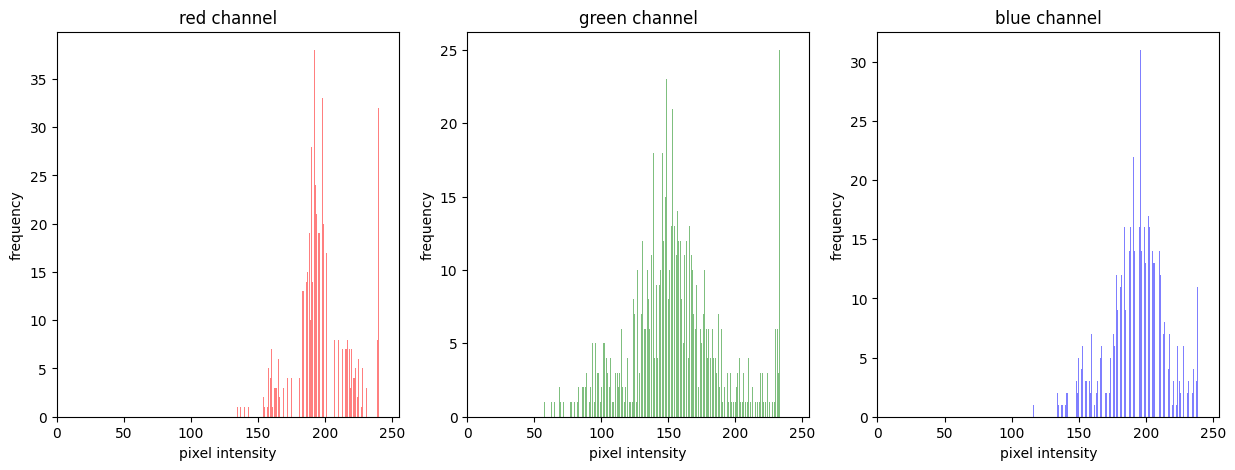

In [12]:
# plot the histogram of pixel intensities for each channel
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(image_rdm[:,:,0].flatten(), bins=256, color='red', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("red channel")
plt.subplot(1,3,2)
plt.hist(image_rdm[:,:,1].flatten(), bins=256, color='green', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("green channel")
plt.subplot(1,3,3)
plt.hist(image_rdm[:,:,2].flatten(), bins=256, color='blue', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("blue channel")
plt.show()

mean: [188.83897503 135.91045926 179.98635682]
std: [31.53896524 45.07444572 31.72982184]


Value with normalisation
mean normalized: [0.740545   0.53298219 0.70582885]
std normalized: [0.12368222 0.17676253 0.12443067]


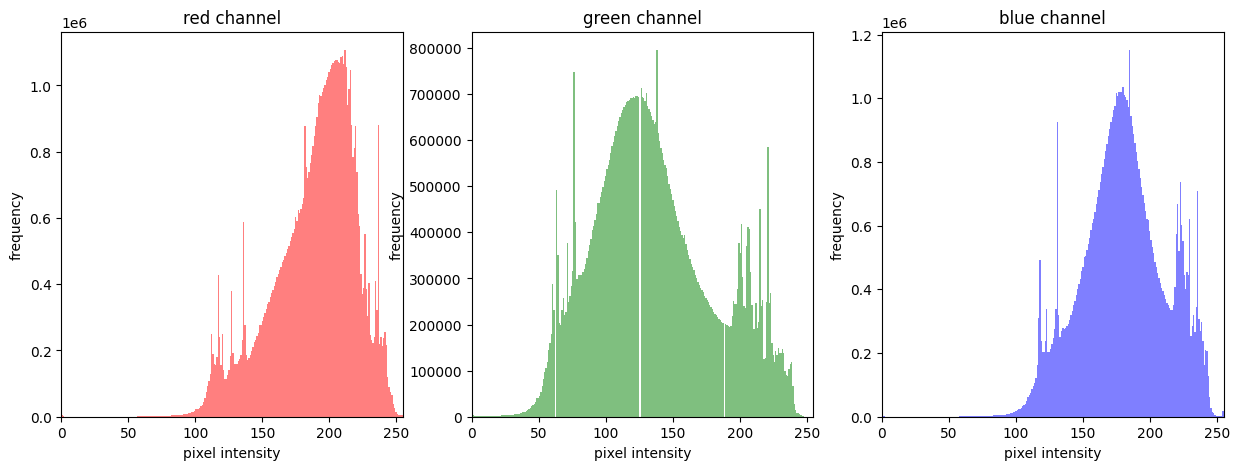

In [13]:
# generelyze for all the images in the training dataset.
mean = np.mean(train_images, axis=(0,1,2))
std = np.std(train_images, axis=(0,1,2))
print("mean:", mean)
print("std:", std)
mean_norm = mean / 255.0
std_norm = std / 255.0
print("\n")
print("Value with normalisation")
print("mean normalized:", mean_norm)
print("std normalized:", std_norm)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(train_images[:,:,:,0].flatten(), bins=256, color='red', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("red channel")
plt.subplot(1,3,2)
plt.hist(train_images[:,:,:,1].flatten(), bins=256, color='green', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("green channel")
plt.subplot(1,3,3)
plt.hist(train_images[:,:,:,2].flatten(), bins=256, color='blue', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("blue channel")
plt.show()

### Q1.2 – Pixel intensity statistics


The mean and standard deviation of pixel intensities were computed for a randomly selected training image. The obtained values were approximately mean = [188.8, 135.9, 180.0] and standard deviation = [31.5, 45.1, 31.7] in the [0,255] range. When rescaled to the [0,1] range, the mean values are around [0.74, 0.53, 0.71] and the standard deviations around [0.12, 0.18, 0.12]. These statistics differ from the commonly used normalization values derived from ImageNet (mean ≈ [0.485, 0.456, 0.406], std ≈ [0.229, 0.224, 0.225]). This difference is expected because histology images exhibit characteristic color distributions caused by hematoxylin–eosin staining, resulting in dominant pink and purple tones. Consequently, ImageNet normalization may not be optimal for this dataset, and it is preferable to compute dataset-specific statistics across the entire training set before training the convolutional neural network.

## 2) Dense Network

In this section, we implement a fully connected neural network (Multi-Layer Perceptron) to establish a baseline for the classification task.

Unlike convolutional neural networks, this model does not exploit the spatial structure of images. Instead, each image is flattened into a one-dimensional vector and processed through a sequence of dense layers.

The purpose of this baseline is to provide a reference point for evaluating more advanced architectures introduced later in the project.

The model is composed of multiple hidden layers with ReLU activations and includes dropout regularization to reduce overfitting.

### 2.1 Data Preparation

Before feeding the images into the dense network, we preprocess the data to ensure compatibility with the model.

Each image is normalized using statistics computed on the training set. Then, the images are flattened into vectors, as the MLP requires one-dimensional inputs.

The labels are also reshaped to match the expected format of the loss function.

We apply a normalization transform that converts images to tensors and standardizes each channel using the dataset-specific mean and standard deviation, ensuring that the input data is centered and scaled to improve training stability and convergence.

In [14]:
# Data preparation:
# Normalized data loaders
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# define the transformations for normalisation
transform_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_norm, std_norm)
])
# create the datasets with the transformations
train_ds_norm = PathMNIST(split='train', transform=transform_norm, download=True)
val_ds_norm = PathMNIST(split='val', transform=transform_norm, download=True)
test_dataset = PathMNIST(split='test', transform=transform_norm, download=True)

# create the data loaders
batch_size = 128
train_loader = DataLoader(train_ds_norm, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds_norm, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)



### 2.2 Training and evaluation utilities

Before defining the model itself, we implement reusable functions for training, validation, and evaluation. These utilities allow us to track the evolution of loss and accuracy over epochs, save the best validation model if needed, and compute performance metrics on the test set. Organizing the code in this way makes the experimental pipeline clearer and easier to reuse for the other architectures in the project.

In [15]:
# define train model function
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Confusion matrix function
def plot_confusion_matrix(model, data_loader, title="Confusion Matrix", labels_names=labels_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.squeeze().long().to(device)
            out = model(xb)
            preds = out.argmax(1)
            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(16, 14))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels_names.values()
    )
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
    ax.set_xticklabels(labels_names.values(), rotation=90, ha="center", fontsize=14)
    ax.set_yticklabels(labels_names.values(), fontsize=14)
    ax.set_title(title, fontsize=25)
    ax.set_xlabel('Predicted', fontsize=18)
    ax.set_ylabel('True', fontsize=18)
    plt.tight_layout()
    plt.show()
    return cm, all_labels, all_preds

# evaluate the model
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss / total, 100.0 * correct / total, np.array(all_preds), np.array(all_labels)


# define train model function
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, labels_names=labels_names):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # Training
        model.train()
        loss_sum, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.squeeze().long().to(device)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(xb)
            correct += (out.argmax(1) == yb).sum().item()
            total += len(xb)
        history["train_loss"].append(loss_sum / total)
        history["train_acc"].append(correct / total)

        # Validation
        model.eval()
        loss_sum, correct, total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb= xb.to(device)
                yb = yb.squeeze().long().to(device)
                out = model(xb)
                loss = criterion(out, yb)
                loss_sum += loss.item() * len(xb)
                correct += (out.argmax(1) == yb).sum().item()
                total += len(xb)
        history["val_loss"].append(loss_sum / total)
        history["val_acc"].append(correct / total)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} — "
                  f"train_acc: {history['train_acc'][-1]:.3f}, "
                  f"val_acc: {history['val_acc'][-1]:.3f}")

    plot_confusion_matrix(
        model = model,
        data_loader = val_loader,
        title=f"Confusion Matrix",
        labels_names = labels_names
    )

    return history

criterion = nn.CrossEntropyLoss()

Using device: cuda


We also define a visualization function to plot the training history. Displaying the evolution of training and validation loss and accuracy is important to assess convergence, detect overfitting, and compare models more effectively.

In [16]:
# create the function to plot the training history
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"],   label="Val")
    ax1.set_title(f"{title} — Loss"); ax1.legend()
    ax2.plot(history["train_acc"], label="Train")
    ax2.plot(history["val_acc"],   label="Val")
    ax2.set_title(f"{title} — Accuracy"); ax2.legend()
    plt.tight_layout(); plt.show()

### 2.3 Dense network architecture

We now define the dense baseline model. Following the project instructions, the architecture contains at least two hidden layers and dropout regularization. The hidden fully connected layers learn nonlinear combinations of pixel intensities, while the dropout layers help reduce overfitting by randomly deactivating a fraction of neurons during training. Even though this model does not explicitly exploit spatial information, it provides an essential baseline for the rest of the project.

In [17]:
# define the MLP model from sratch with least 2 hidden layers and dropout
class DenseNetwork(nn.Module):
    """MLP with 2 hidden layers and dropout."""
    def __init__(self, input_dim=3*28*28, n_classes=num_classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)
# print the model summary
mlp_model = DenseNetwork()
print(mlp_model)


DenseNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=2352, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=9, bias=True)
  )
)


### 2.4 Training the dense baseline

We train the dense network on the PathMNIST training set and monitor its performance on the validation set across epochs. The objective here is to establish a first benchmark in terms of classification accuracy, validation loss, and confusion patterns. This baseline will later allow us to quantify the benefit of using convolutional architectures and transfer learning.

Training MLP model...
Epoch 5/30 — train_acc: 0.655, val_acc: 0.669
Epoch 10/30 — train_acc: 0.693, val_acc: 0.692
Epoch 15/30 — train_acc: 0.719, val_acc: 0.700
Epoch 20/30 — train_acc: 0.743, val_acc: 0.708
Epoch 25/30 — train_acc: 0.764, val_acc: 0.718
Epoch 30/30 — train_acc: 0.780, val_acc: 0.710


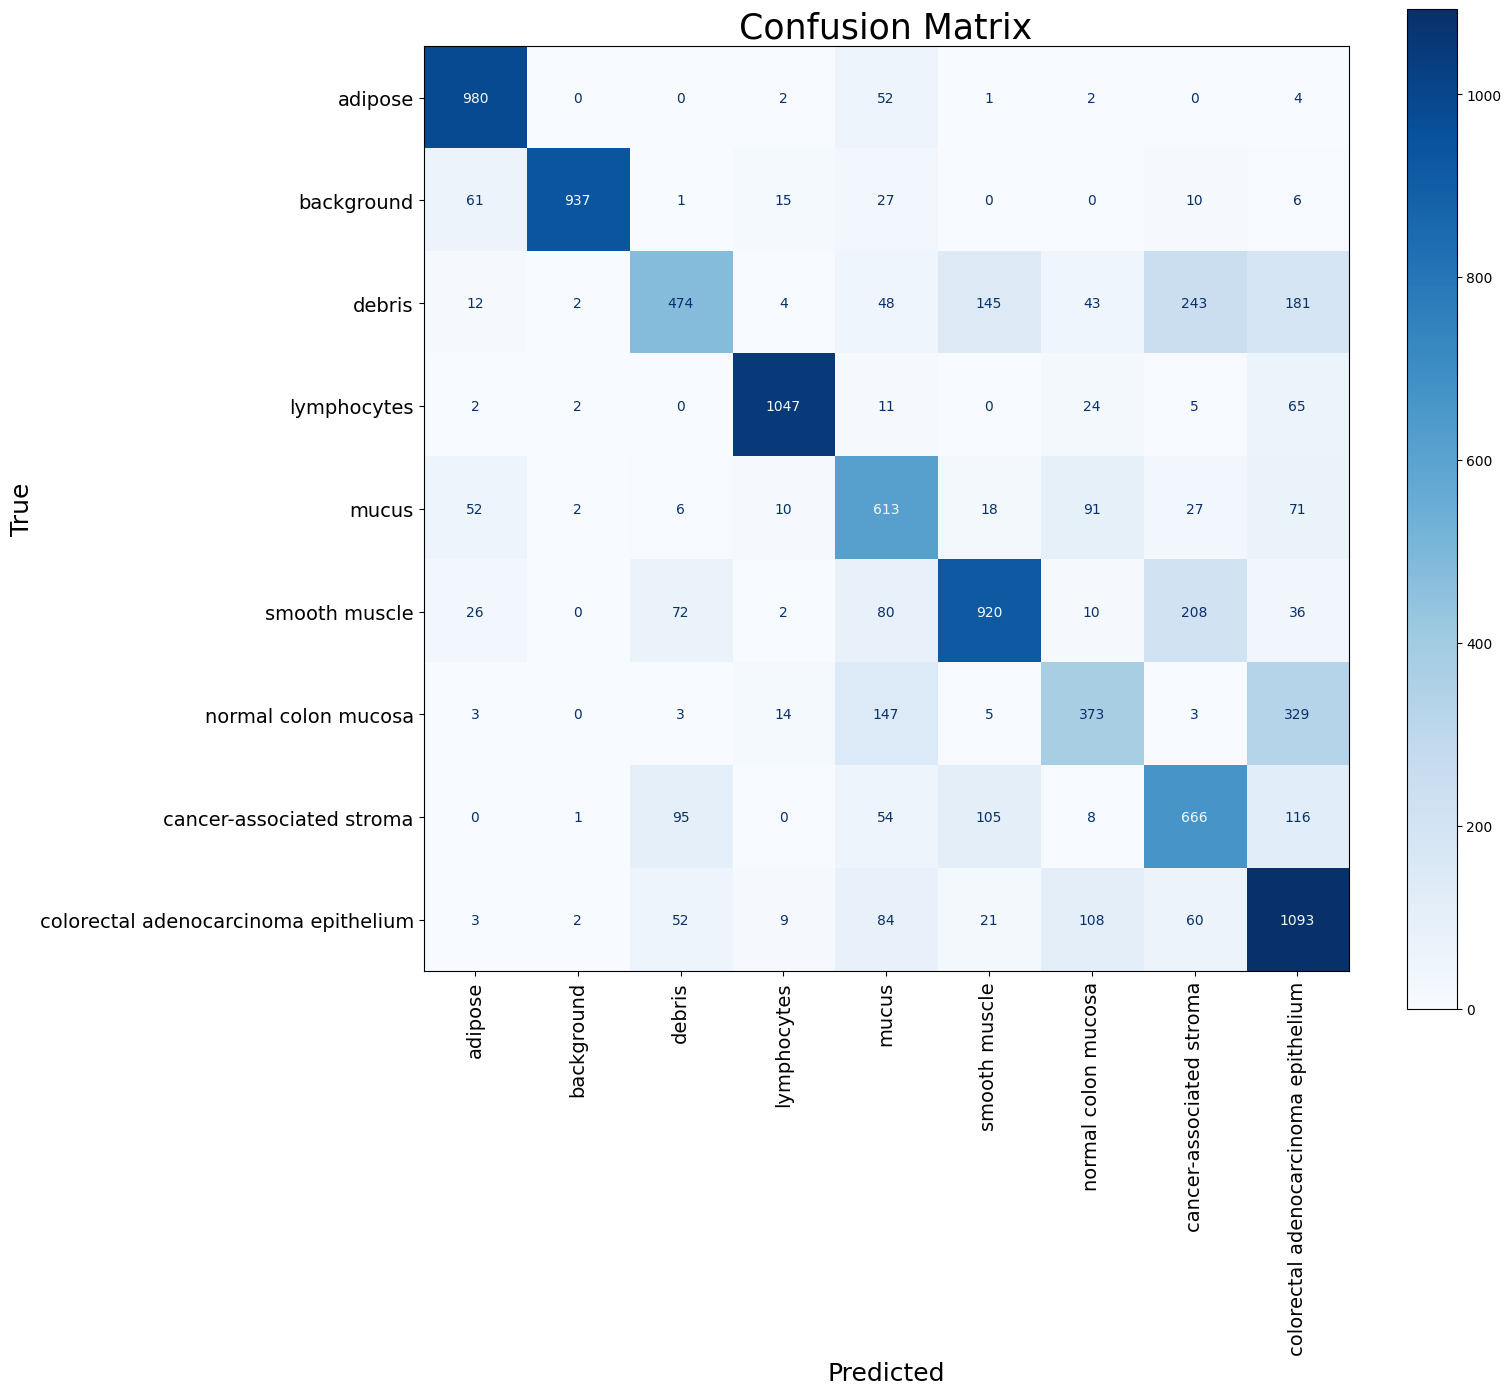

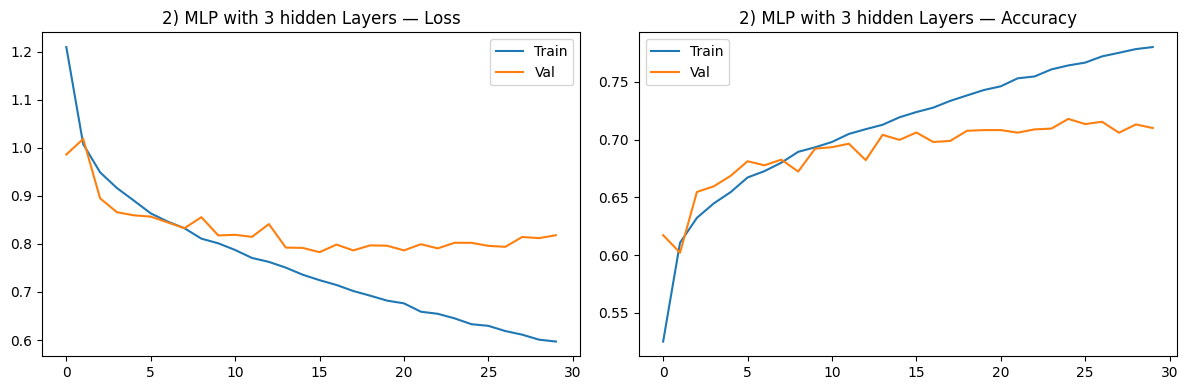

In [18]:
print("Training MLP model...")
history_mlp = train_model(mlp_model, train_loader, val_loader, epochs=30, lr=1e-3, labels_names=labels_names)
plot_history(history_mlp, title="2) MLP with 3 hidden Layers")

### Q2.2 – Largest confusion in the matrix

The largest off-diagonal confusion occurs for the **Debris** class, which is frequently misclassified as **Cancer-Associated Stroma (293 samples)** and **Colorectal Adenocarcinoma Epithelium (171 samples)**. This indicates that the model struggles to distinguish debris from more structured pathological tissues.

This confusion is likely due to the visual similarity between these classes at low resolution (28×28 pixels). Debris often contains irregular textures and fragmented tissue components, which may resemble stromal or tumoral patterns when spatial details are limited. As a result, the model tends to associate these noisy or heterogeneous regions with biologically meaningful structures.

Another significant confusion appears between **Normal Colon Mucosa** and **Colorectal Adenocarcinoma Epithelium (211 samples)**. This is expected, as both classes share epithelial characteristics, and subtle morphological differences may not be well captured by the model.

These results highlight the limitations of the current architecture in capturing fine-grained histological patterns, especially for classes with overlapping visual features. This motivates the use of more advanced models, such as convolutional networks and transfer learning, which are better suited for extracting spatial and structural information.

### 2.5 Exact values requested in the instructions

Q.1) The project instructions require the exact test accuracy and the exact validation loss at epoch 1, epoch 10, and the final epoch. We therefore extract these values directly from the training logs instead of rounding them, so that the notebook answers the question precisely and transparently.

In [19]:
print("===== REPORT VALUES =====")
print("Exact values of the validation loss at epoch 1, epoch 10 and the final epoch.")
print(f"Epoch 1  - val_loss: {history_mlp['val_loss'][0]}")
print(f"Epoch 10 - val_loss: {history_mlp['val_loss'][9]}")
print(f"Final epoch ({len(history_mlp['val_loss'])}) - val_loss: {history_mlp['val_loss'][-1]}")
print("Exact values of the validation accuracy at the same epochs.")
print(f"Epoch 1  - val_acc: {history_mlp['val_acc'][0]}")
print(f"Epoch 10 - val_acc: {history_mlp['val_acc'][9]}")
print(f"Final epoch ({len(history_mlp['val_acc'])}) - val_acc: {history_mlp['val_acc'][-1]}")

===== REPORT VALUES =====
Exact values of the validation loss at epoch 1, epoch 10 and the final epoch.
Epoch 1  - val_loss: 0.9863084165013728
Epoch 10 - val_loss: 0.8177951737100341
Final epoch (30) - val_loss: 0.8181670267359823
Exact values of the validation accuracy at the same epochs.
Epoch 1  - val_acc: 0.6172530987604958
Epoch 10 - val_acc: 0.6921231507397041
Final epoch (30) - val_acc: 0.710015993602559


In [20]:
# Test evaluation
test_loss_mlp, test_acc_mlp, preds_mlp, labels_mlp = evaluate(mlp_model, test_loader, criterion, device)
print(f"\nMLP Test Accuracy: {test_acc_mlp:.2f}%")


MLP Test Accuracy: 62.38%


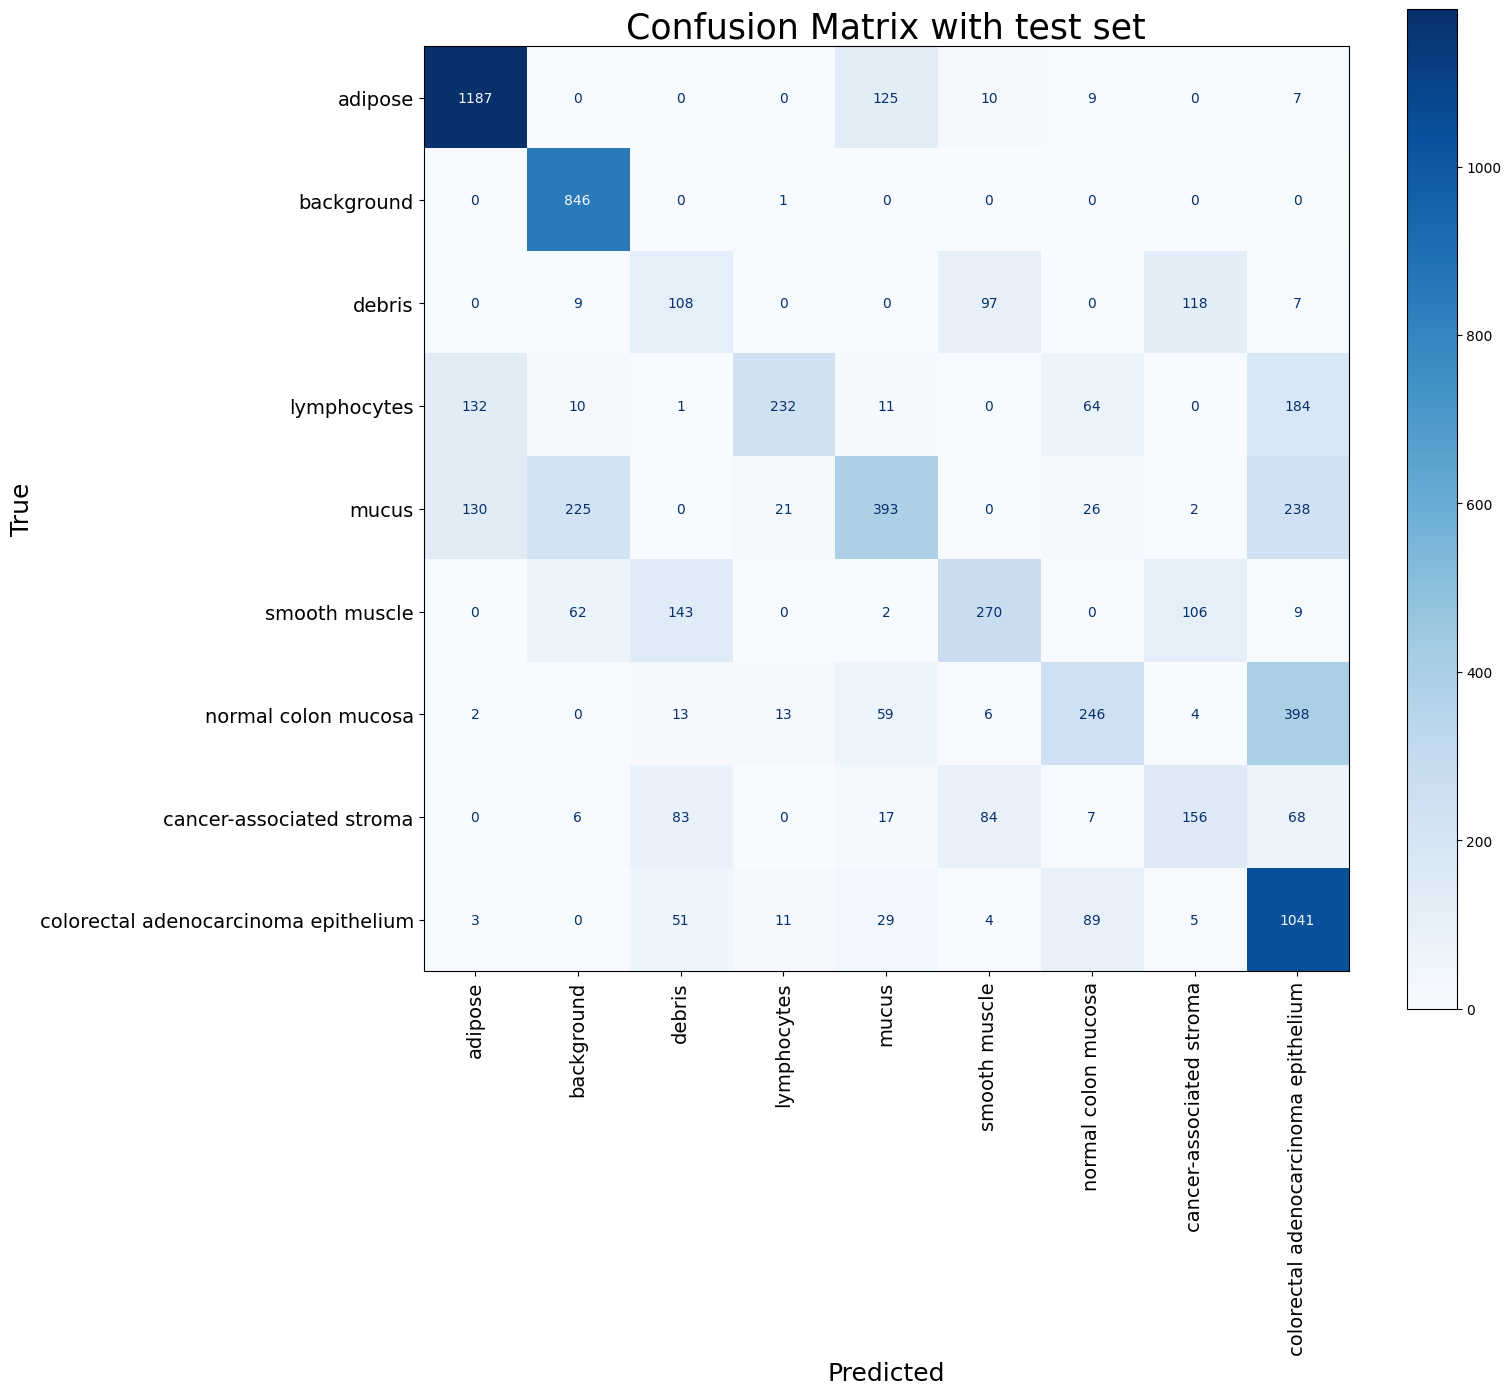

In [22]:
mc = plot_confusion_matrix(mlp_model, test_loader, title="Confusion Matrix with test set", labels_names=labels_names)


Between epoch 1 and epoch 10, the model shows a significant improvement, with the validation loss decreasing from 0.996 to 0.816 and the validation accuracy increasing from 61.4% to 69.2%. However, between epoch 10 and the final epoch (30), the improvement becomes much smaller, with the validation loss only slightly decreasing to 0.799 and the validation accuracy reaching 71.1%. This suggests that the model starts to converge after around 10 epochs, with diminishing returns from additional training.

## 3. CNN from Scratch

After establishing a dense baseline, we move to a convolutional neural network. Unlike a multilayer perceptron, a CNN preserves the spatial organization of the image and learns local patterns through convolutional filters. This makes CNNs particularly well suited for histology images, where texture, shape, and spatial arrangement are essential for distinguishing tissue types. In this part, we design a regularized CNN with multiple convolutional blocks, batch normalization, dropout, and data augmentation.

This convolutional neural network is structured into three hierarchical convolutional blocks with increasing channel depth (from 32 to 128), each combining convolution, batch normalization, ReLU activation, max pooling, and dropout to progressively extract and regularize spatial features, followed by a fully connected classifier that maps the learned representations to the final class predictions.

In [23]:
class CNNFromScratch(nn.Module):
    """CNN with 3 conv blocks, batch norm, and dropout."""
    def __init__(self, n_classes=num_classes):
        super().__init__()
        # Block 1: 3 -> 32
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        # Block 2: 32 -> 64
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        # Block 3: 64 -> 128
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

In [24]:
cnn_model = CNNFromScratch(n_classes=num_classes).to(device)

In [25]:
print("===== CNN FROM SCRATCH STRUCTURE =====")
cnn_model

===== CNN FROM SCRATCH STRUCTURE =====


CNNFromScratch(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   

In [27]:
cnn_noaug = CNNFromScratch(n_classes=num_classes).to(device)

Epoch 5/40 — train_acc: 0.854, val_acc: 0.908
Epoch 10/40 — train_acc: 0.899, val_acc: 0.941
Epoch 15/40 — train_acc: 0.921, val_acc: 0.940
Epoch 20/40 — train_acc: 0.929, val_acc: 0.957
Epoch 25/40 — train_acc: 0.936, val_acc: 0.950
Epoch 30/40 — train_acc: 0.942, val_acc: 0.959
Epoch 35/40 — train_acc: 0.946, val_acc: 0.955
Epoch 40/40 — train_acc: 0.948, val_acc: 0.954


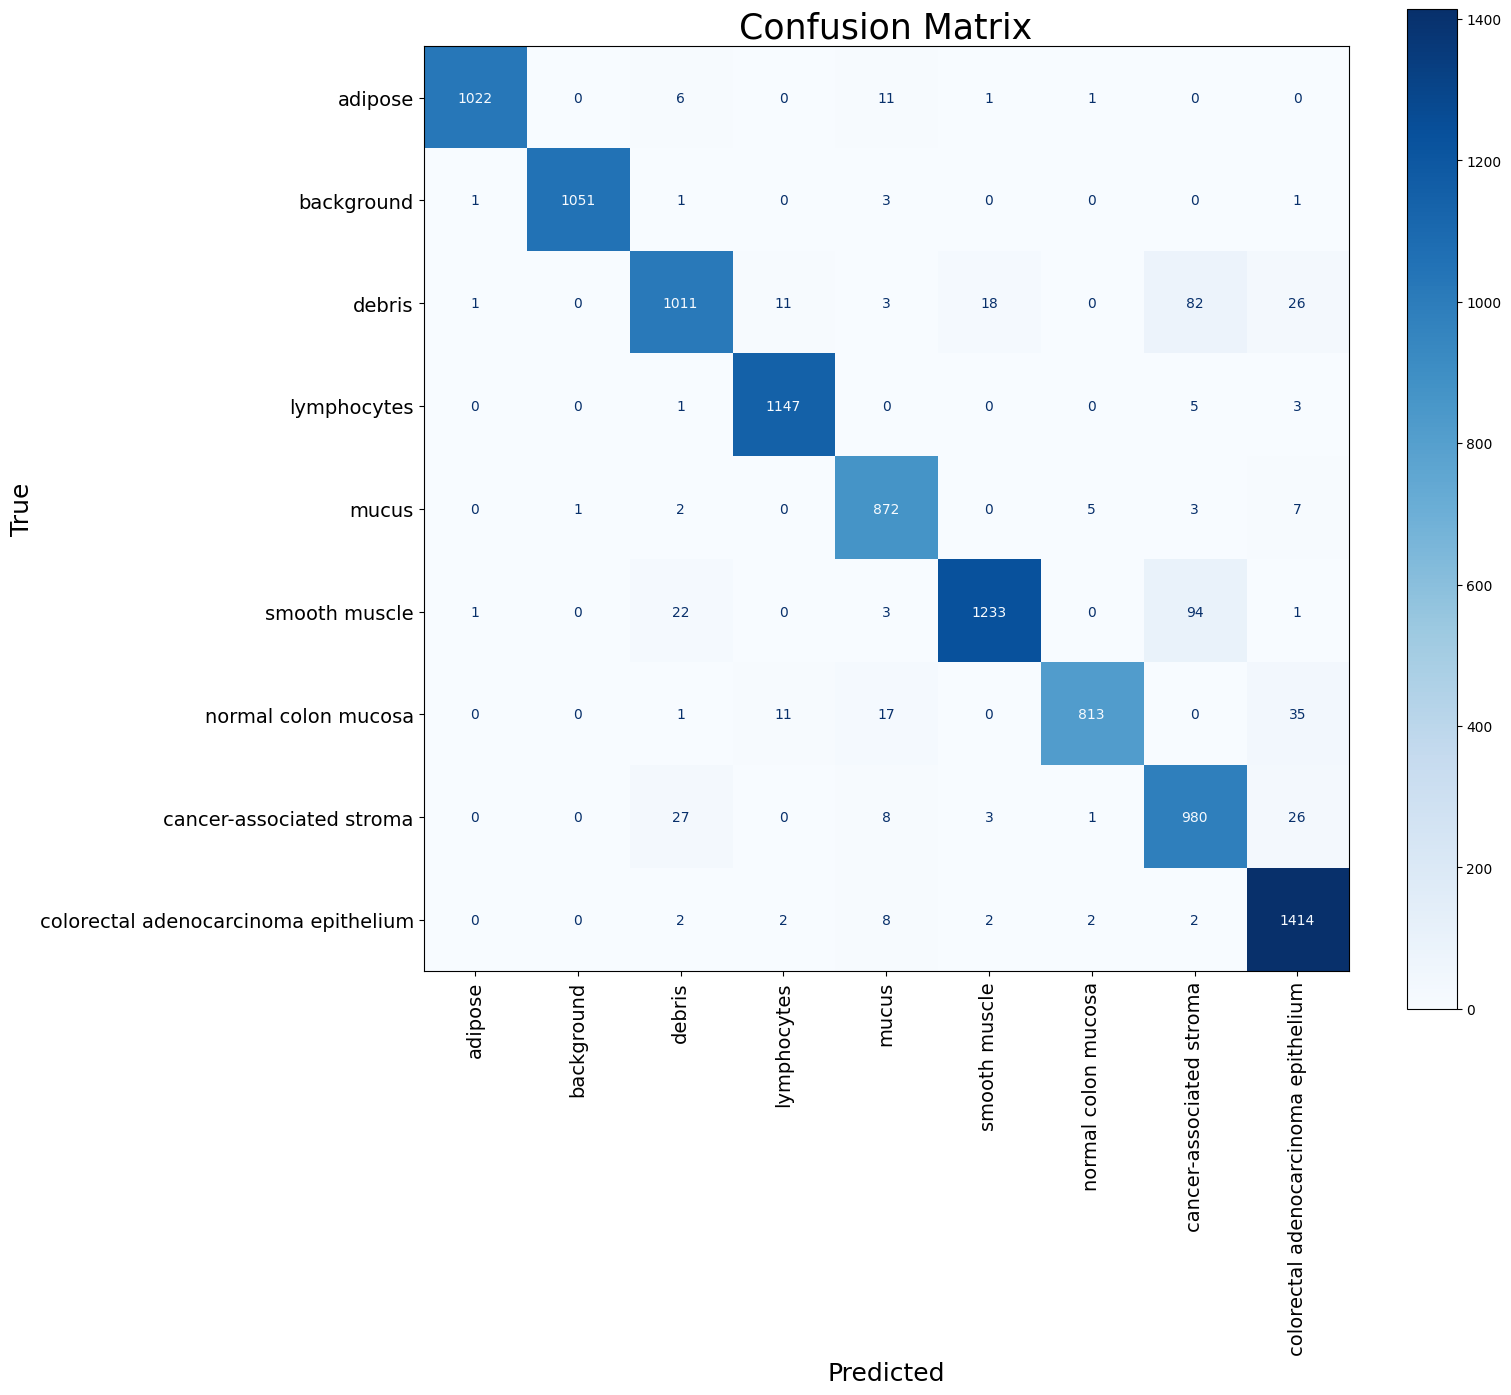

In [28]:
optimizer_cnn_noaug = optim.Adam(cnn_noaug.parameters(), lr=1e-3)
history_cnn_noaug = train_model(cnn_noaug, train_loader, val_loader, epochs=40, lr=1e-3, labels_names=labels_names)


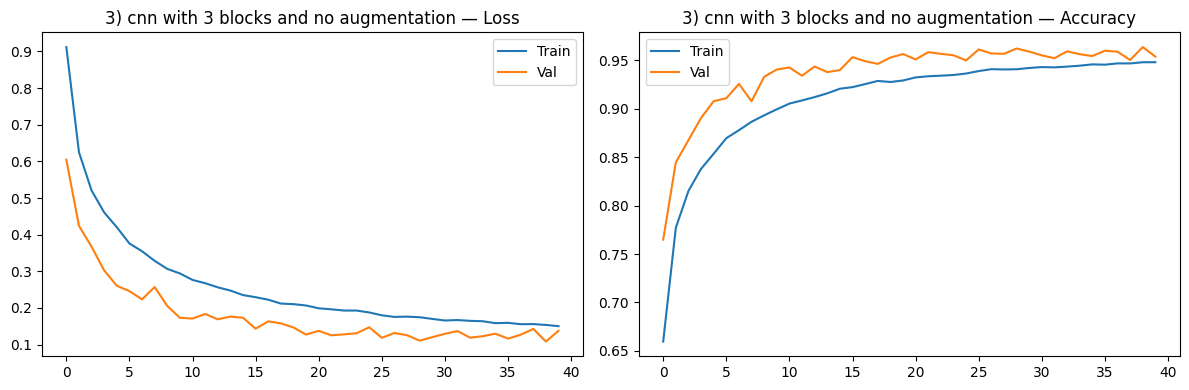

In [29]:
plot_history(history_cnn_noaug, title="3) cnn with 3 blocks and no augmentation")

At which epoch does
the gap between training accuracy and validation accuracy exceed 15 percentage points for
the first time? Report the exact epoch number and both accuracy values.

In [30]:
# Q3.1 — Find epoch where gap > 15%
# Define a find gap epoch function
def find_gap_epoch(history) -> str:
    print("\nQ3.1 — Overfitting analysis:")

    train_acc = np.array(history["train_acc"])
    val_acc = np.array(history["val_acc"])
    gaps = train_acc - val_acc

    threshold = 0.15

    for i, gap in enumerate(gaps):
        if gap > threshold:
            print(f"  First epoch with gap > 15%: Epoch {i+1}")
            print(f"  Train Acc: {train_acc[i]*100:.2f}%, Val Acc: {val_acc[i]*100:.2f}%")
            print(f"  Gap: {gap*100:.2f}%")
            return f"First epoch with gap > 15%: Epoch {i+1}"

    max_gap_idx = np.argmax(gaps)
    print(f"  Max gap at epoch {max_gap_idx+1}: {train_acc[max_gap_idx]*100:.2f}% - {val_acc[max_gap_idx]*100:.2f}% = {gaps[max_gap_idx]*100:.2f}%")
    return f"Gap never exceeded 15%. Max gap at epoch {max_gap_idx+1}: {abs(gaps[max_gap_idx])*100:.2f}%"


In [31]:
# print the test
find_gap_epoch(history_cnn_noaug)


Q3.1 — Overfitting analysis:
  Max gap at epoch 38: 94.69% - 95.04% = -0.35%


'Gap never exceeded 15%. Max gap at epoch 38: 0.35%'

In [32]:
# Test evaluation
test_loss_cnn_noaug, test_acc_cnn_noaug, preds_cnn_noaug, labels_cnn_noaug = evaluate(cnn_noaug, test_loader, criterion, device)
print(f"\nCNN Without DataAug Test Accuracy: {test_acc_cnn_noaug:.2f}%")


CNN Without DataAug Test Accuracy: 83.50%


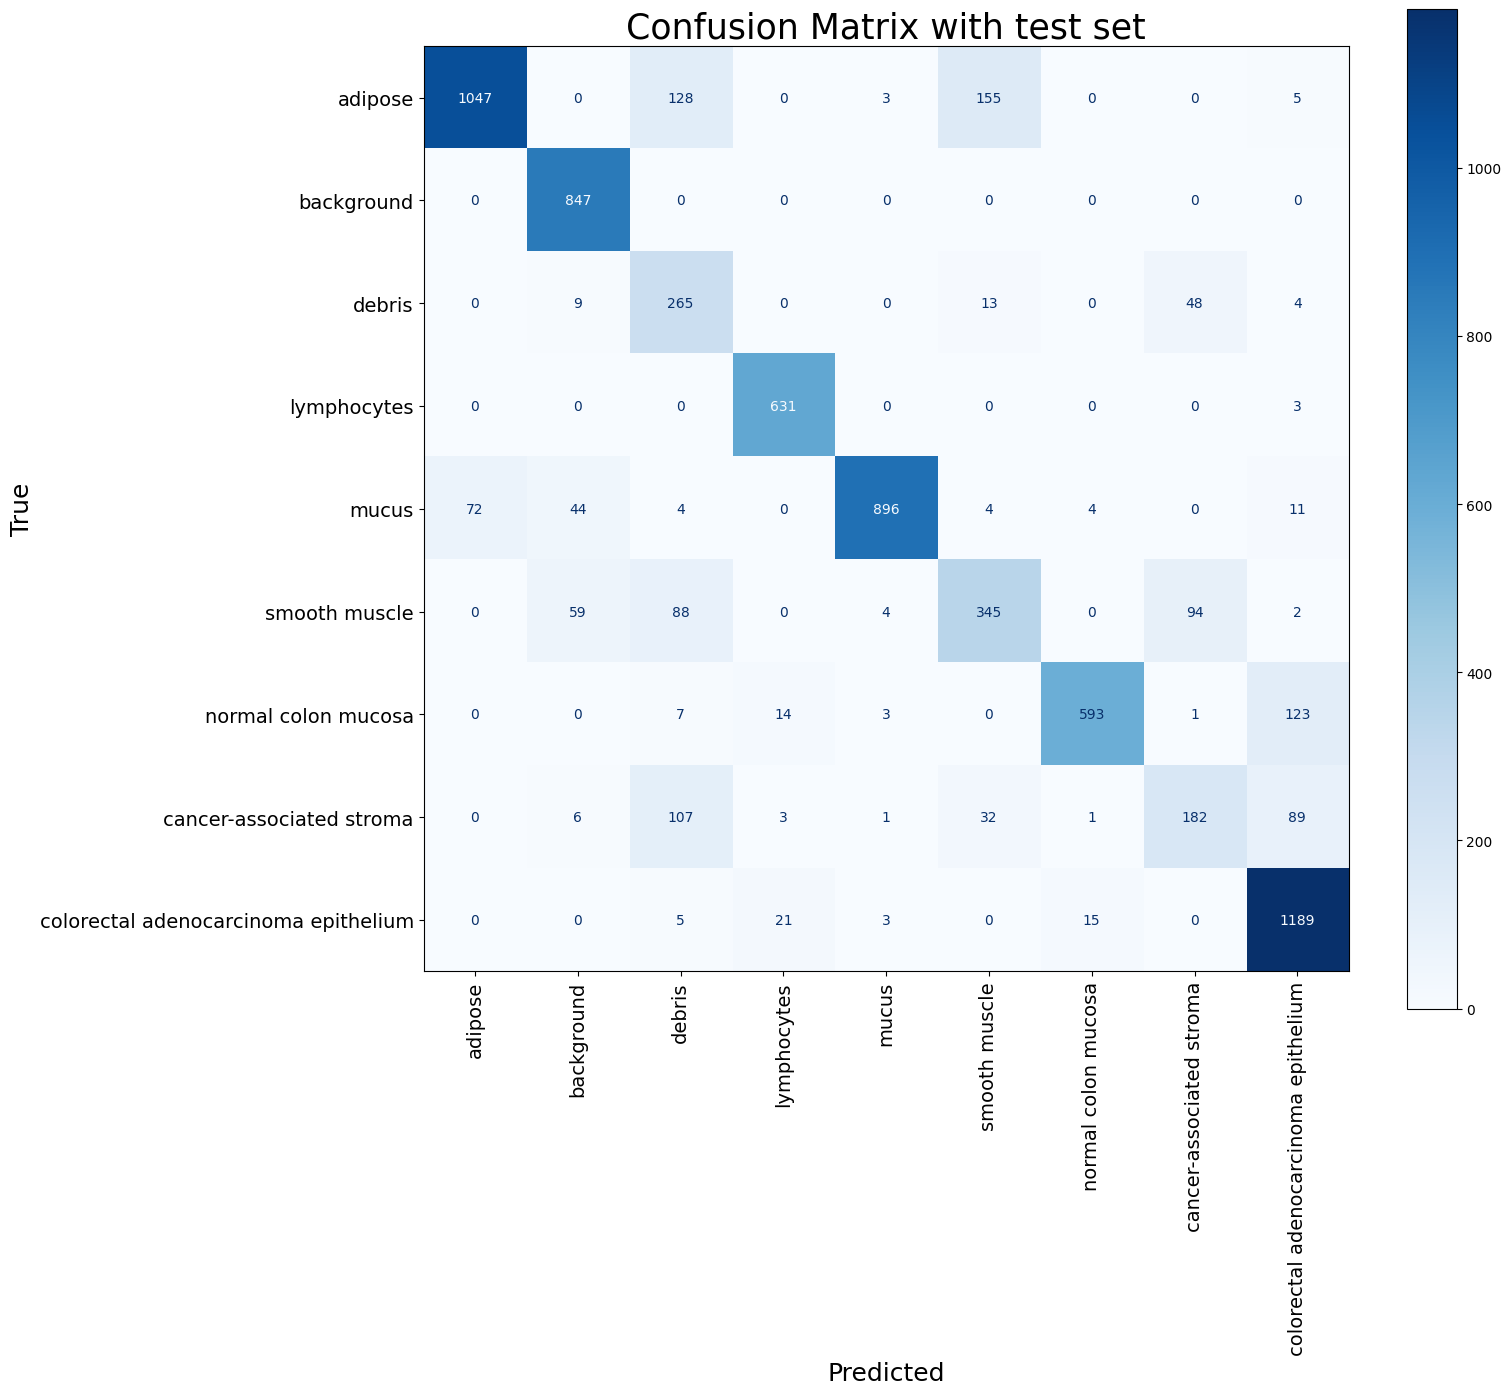

In [33]:
mc = plot_confusion_matrix(cnn_noaug, test_loader, title="Confusion Matrix with test set", labels_names=labels_names)


### CNN without data augmentation – Analysis

The CNN trained without data augmentation shows strong and stable learning behavior. The training and validation loss decrease rapidly during the first epochs and then gradually converge, while the accuracy steadily increases, reaching approximately 94% on the training set and around 96% on the validation set.

The confusion matrix confirms this strong performance, with most predictions concentrated along the diagonal, indicating high classification accuracy across all tissue types. Classes such as adipose tissue, background, lymphocytes, and colorectal adenocarcinoma epithelium are almost perfectly classified.

### CNN with data augmentation

To improve the model’s generalization ability and make it more robust to variations in tissue appearance, we train a new CNN using data augmentation techniques that introduce controlled transformations of the input images during training.

Q3.2 — Augmentation Analysis:
- EXPLOITS histology property: RandomHorizontalFlip and RandomVerticalFlip.
  Histology patches have no canonical orientation — tissue looks valid in any rotation/flip.
- HARMFUL for histology: ColorJitter with extreme hue shifts.
  H&E staining produces specific purple (hematoxylin) and pink (eosin) colors that encode
  biological meaning. Randomly shifting hue would destroy this diagnostic information
  and create unrealistic training examples.

In [35]:

cnn_aug = CNNFromScratch(n_classes=num_classes).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Epoch 5/40 — train_acc: 0.823, val_acc: 0.893
Epoch 10/40 — train_acc: 0.870, val_acc: 0.918
Epoch 15/40 — train_acc: 0.888, val_acc: 0.922
Epoch 20/40 — train_acc: 0.899, val_acc: 0.942
Epoch 25/40 — train_acc: 0.905, val_acc: 0.939
Epoch 30/40 — train_acc: 0.912, val_acc: 0.954
Epoch 35/40 — train_acc: 0.917, val_acc: 0.958
Epoch 40/40 — train_acc: 0.919, val_acc: 0.935


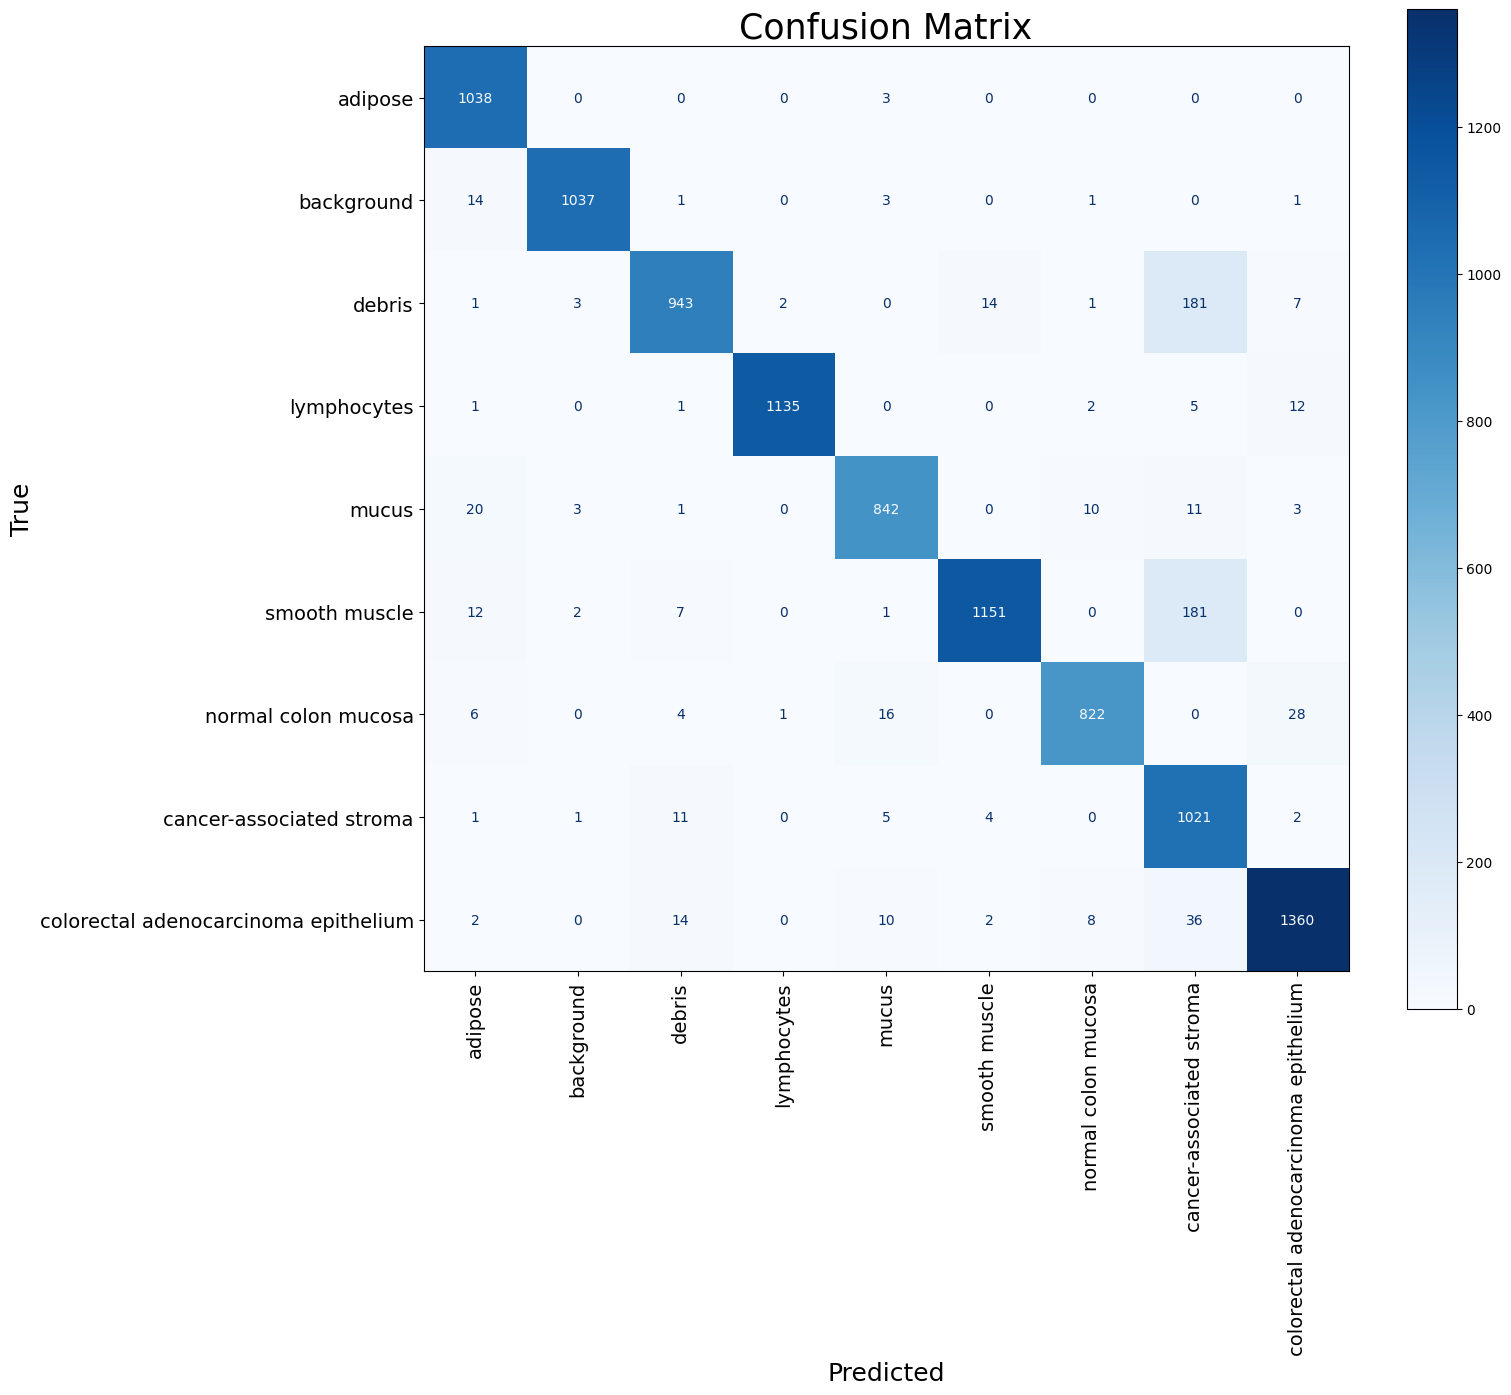

In [36]:
import torchvision.transforms.v2 as T

transform_aug = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean_norm, std=std_norm)
])

train_ds_aug = PathMNIST(split='train', transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_ds_aug, batch_size=batch_size, shuffle=True, num_workers=2)
optimizer_cnn_aug = optim.Adam(cnn_aug.parameters(), lr=1e-3)
history_cnn_aug = train_model(cnn_aug, train_loader_aug, val_loader, epochs=40, lr=1e-3, labels_names=labels_names)


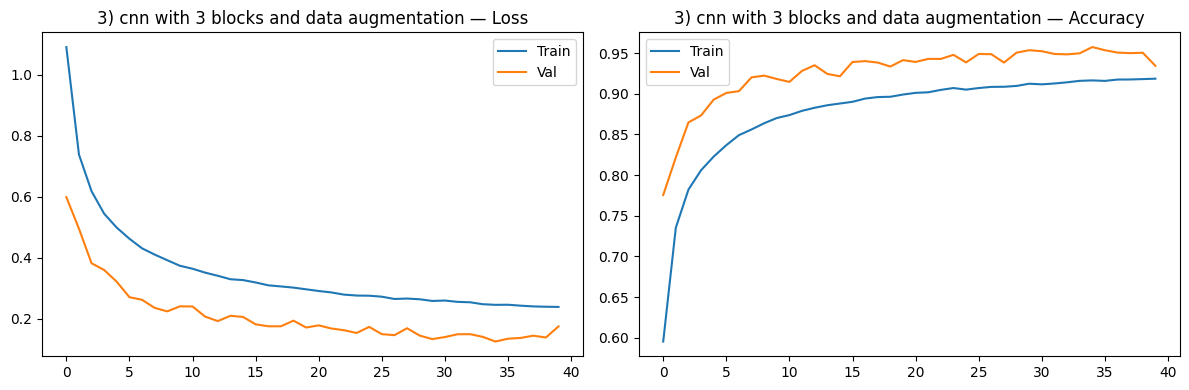

In [37]:
plot_history(history_cnn_aug, title="3) cnn with 3 blocks and data augmentation")

In [38]:
# print the train val test
find_gap_epoch(history_cnn_aug)


Q3.1 — Overfitting analysis:
  Max gap at epoch 40: 91.87% - 93.45% = -1.58%


'Gap never exceeded 15%. Max gap at epoch 40: 1.58%'

#### Q 3.3 calculate the number of parameters
Print the total number of trainable parameters in the CNN.

In [39]:
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
# Manual calculation for first conv layer:
# Conv2d(3, 32, 3, padding=1): weights = 3 * 32 * 3 * 3 = 864, bias = 32 => total = 896
first_conv_params = 3 * 32 * 3 * 3 + 32
print(f"First conv layer (manual): {first_conv_params} parameters")
print(f"First conv layer (from model): {sum(p.numel() for p in cnn_model.block1[0].parameters())}")

Total trainable parameters: 437,545
First conv layer (manual): 896 parameters
First conv layer (from model): 896




The model contains a total of 437,545 trainable parameters. After a manual calculate, we obtain 896 for the first conv layer QED !

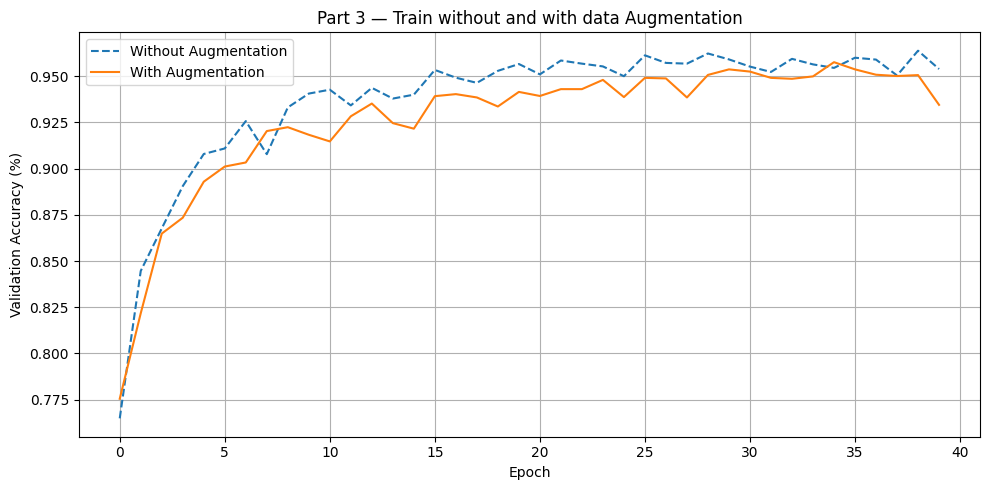

In [40]:
# Comparison plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_cnn_noaug["val_acc"], label='Without Augmentation', linestyle='--')
ax.plot(history_cnn_aug["val_acc"], label='With Augmentation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Part 3 — Train without and with data Augmentation')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [41]:
def compare_results(hist_1, hist_2, name_1="Model 1", name_2="Model 2"):
    acc_1 = max(hist_1["val_acc"])
    acc_2 = max(hist_2["val_acc"])

    if acc_1 > acc_2:
        best_name = name_1
        drop = acc_1 - acc_2
        best_accuracy = acc_1
    else:
        best_name = name_2
        drop = acc_2 - acc_1
        best_accuracy = acc_2

    print("===== Accuracy Comparison (Best Val Acc) =====")
    print(f"Best model: {best_name}")
    print(f"Max accuracy : {best_accuracy:.4f}")
    print(f"With a difference of {drop:.4f} ({drop*100:.2f}%)")

In [42]:
compare_results(history_cnn_aug, history_cnn_noaug, "With augmentation", "Without augmentation")

===== Accuracy Comparison (Best Val Acc) =====
Best model: Without augmentation
Max accuracy : 0.9638
With a difference of 0.0062 (0.62%)


In [ ]:
# Test evaluation
test_loss_cnn_aug, test_acc_cnn_aug, preds_cnn_aug, labels_cnn_aug = evaluate(cnn_aug, test_loader, criterion, device)
print(f"\nCNN With DataAug Test Accuracy: {test_acc_cnn_aug:.2f}%")

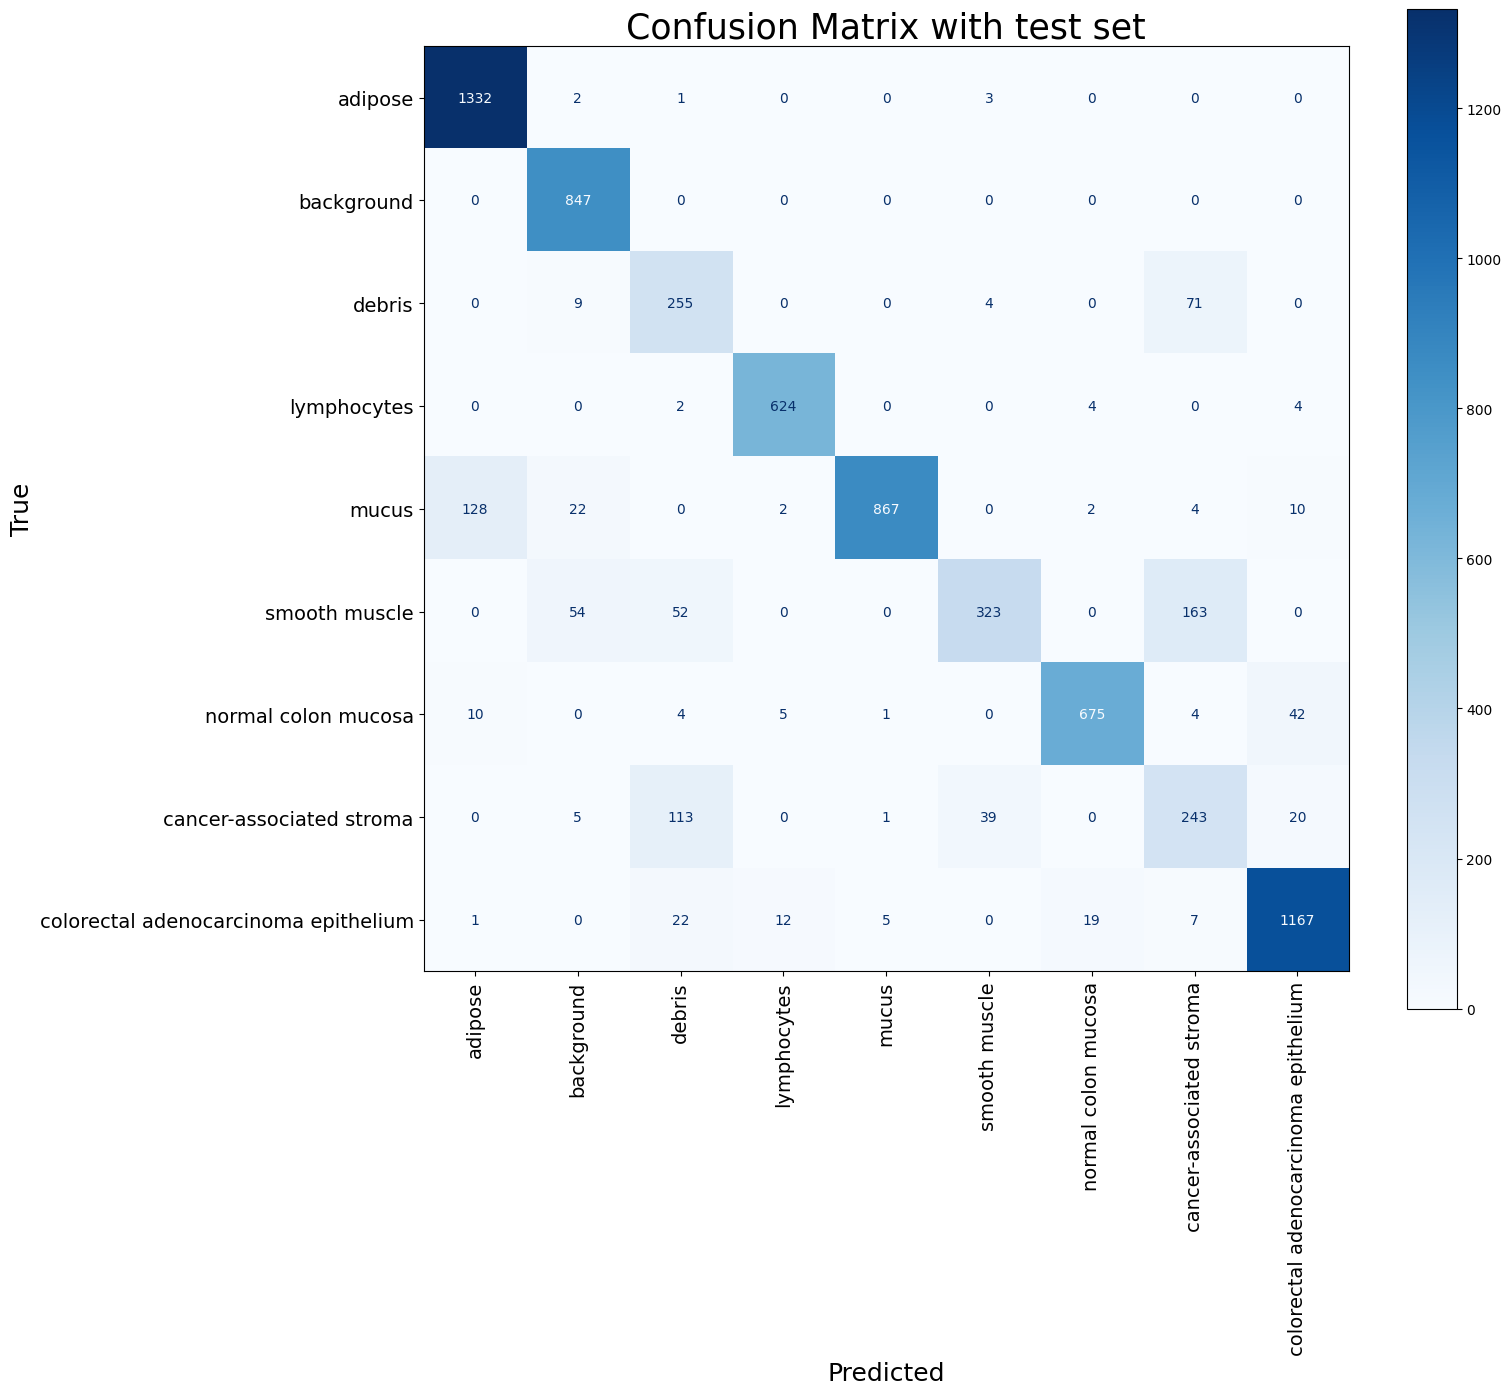

In [43]:
mc = plot_confusion_matrix(cnn_aug, test_loader, title="Confusion Matrix with test set", labels_names=labels_names)


### Comparison of training with and without data augmentation

The training curves show that both models converge to a high validation accuracy, reaching approximately 95–96% after sufficient training. However, their learning dynamics differ noticeably in the early and intermediate epochs.

Without data augmentation, the model learns faster during the first epochs and achieves higher validation accuracy early on. This is expected, as the model sees the exact same images at each epoch, making the optimization easier and more stable. However, this also means the model may rely more on specific patterns present in the training set, increasing the risk of overfitting.

In contrast, the model trained with data augmentation starts with lower validation accuracy and converges more slowly. This is because the input data is continuously perturbed, making the learning task more difficult. Nevertheless, this variability forces the model to learn more robust and invariant features rather than memorizing specific samples.

After convergence, both approaches reach similar performance, with the augmented model slightly catching up to the non-augmented one. This suggests that, for this dataset and model capacity, overfitting is already relatively limited, but data augmentation still provides a regularization effect and improves robustness.

Overall, training without augmentation offers faster convergence, while training with augmentation promotes better generalization, even if the final accuracy gains remain moderate in this case.

## 4. Transfer Learning with ResNet-18
Fine-tune a pretrained ResNet-18 on PathMNIST.
Use ImageNet-pretrained weights.

In [44]:
# Importation of the pretrained ResNet18 model
import torchvision.models as models
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader
resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s] 


To handle the input size mismatch between PathMNIST (28×28) and ResNet18, images were first upscaled to 224×224 following the standard ImageNet setting. However, this introduced excessive interpolation and degraded training performance. A smaller resizing to 96×96 was therefore adopted, offering a better balance between spatial detail preservation and model compatibility, leading to improved results

In [45]:

# Handle the input size mismatch appropriately
# Resize to 96x96 (not 224x224 (question 4.2)) for ResNet
transform_resnet = T.Compose([
    T.Resize((96, 96)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # resnet normalisation values
])
# Smaller batch size because 224x224 images use more memory
train_ds_resnet = PathMNIST(split='train', transform=transform_resnet, download=True)
train_loader_resnet = DataLoader(train_ds_resnet, batch_size=64, shuffle=True)
val_ds_resnet = PathMNIST(split='val', transform=transform_resnet, download=True)
val_loader_resnet = DataLoader(val_ds_resnet, batch_size=64, shuffle=True)
test_ds_resnet = PathMNIST(split='test', transform=transform_resnet, download=True)
test_loader_resnet = DataLoader(test_ds_resnet, batch_size=64, shuffle=True)


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


It's important to adapt the number of output

In [46]:
# adapt the number of output classes
import torch.nn as nn
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

### Run two experiments:

(a) fine-tune only the classification head with all other layers frozen

Epoch 5/10 — train_acc: 0.848, val_acc: 0.865
Epoch 10/10 — train_acc: 0.850, val_acc: 0.857


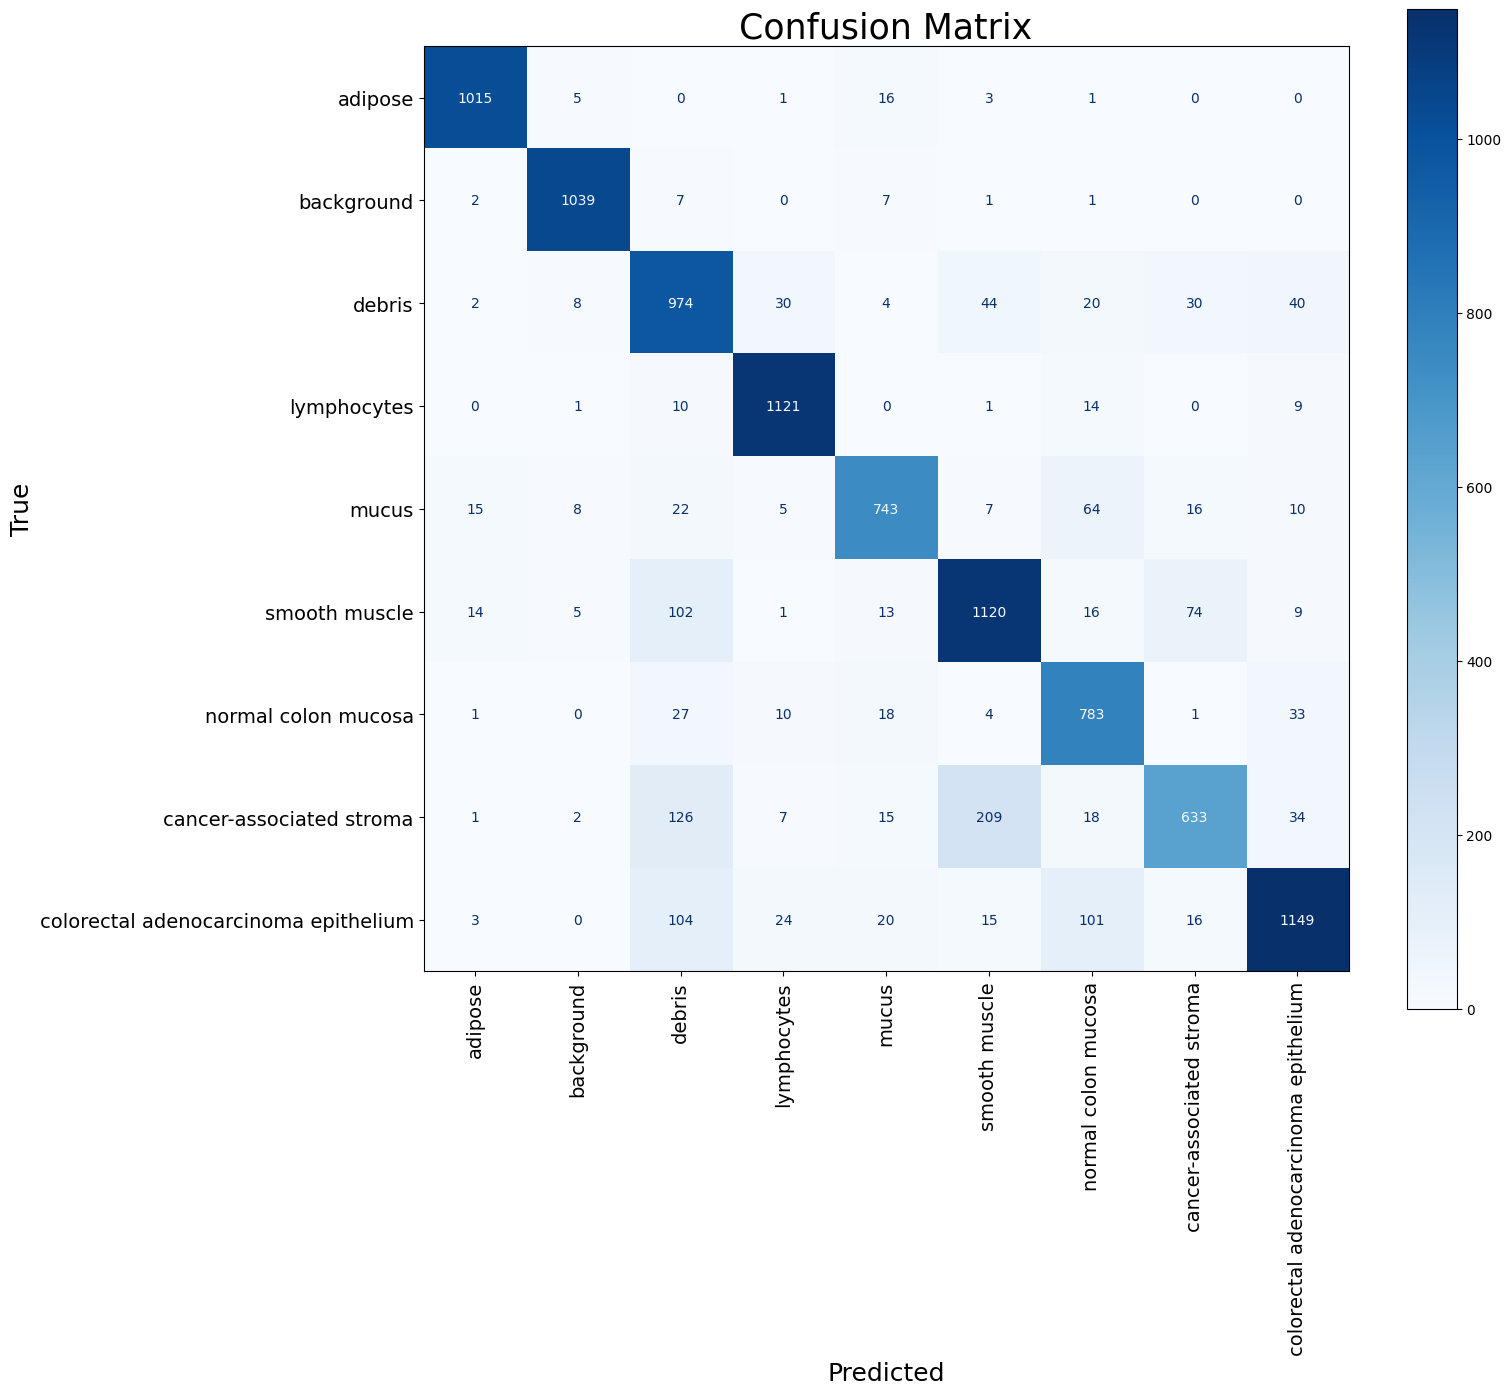

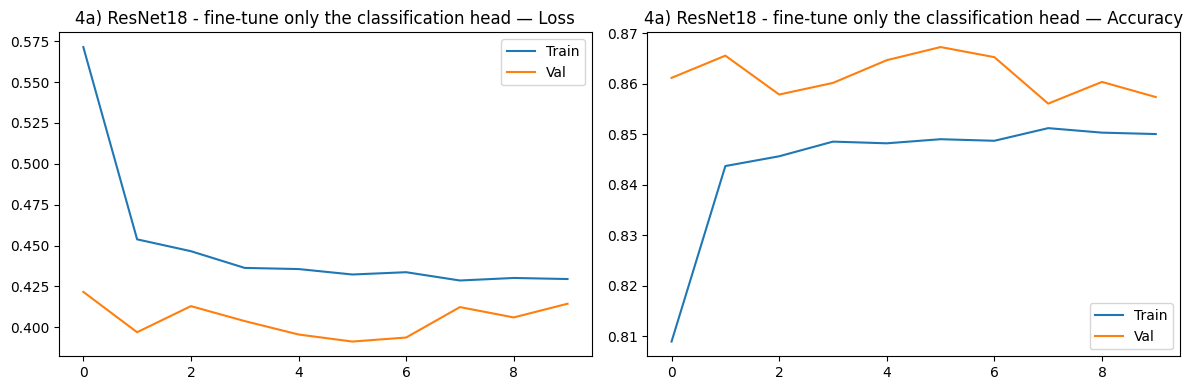

In [47]:
#(a) fine-tune only the classification head with all other layers frozen
for param in resnet18.parameters():
    param.requires_grad = False
for param in resnet18.fc.parameters():
    param.requires_grad = True
# fine-tune the model
history_resnet_a = train_model(resnet18, train_loader_resnet, val_loader_resnet, epochs=10, lr=1e-3, labels_names=labels_names)
plot_history(history_resnet_a, title="4a) ResNet18 - fine-tune only the classification head")

In [48]:
# Test evaluation
test_loss_resnet18, test_acc_resnet18, preds_resnet18, labels_resnet18 = evaluate(resnet18, test_loader_resnet, criterion, device)
print(f"\nResnet First Fine Tune Test Accuracy: {test_acc_resnet18:.2f}%")


Resnet First Fine Tune Test Accuracy: 82.42%


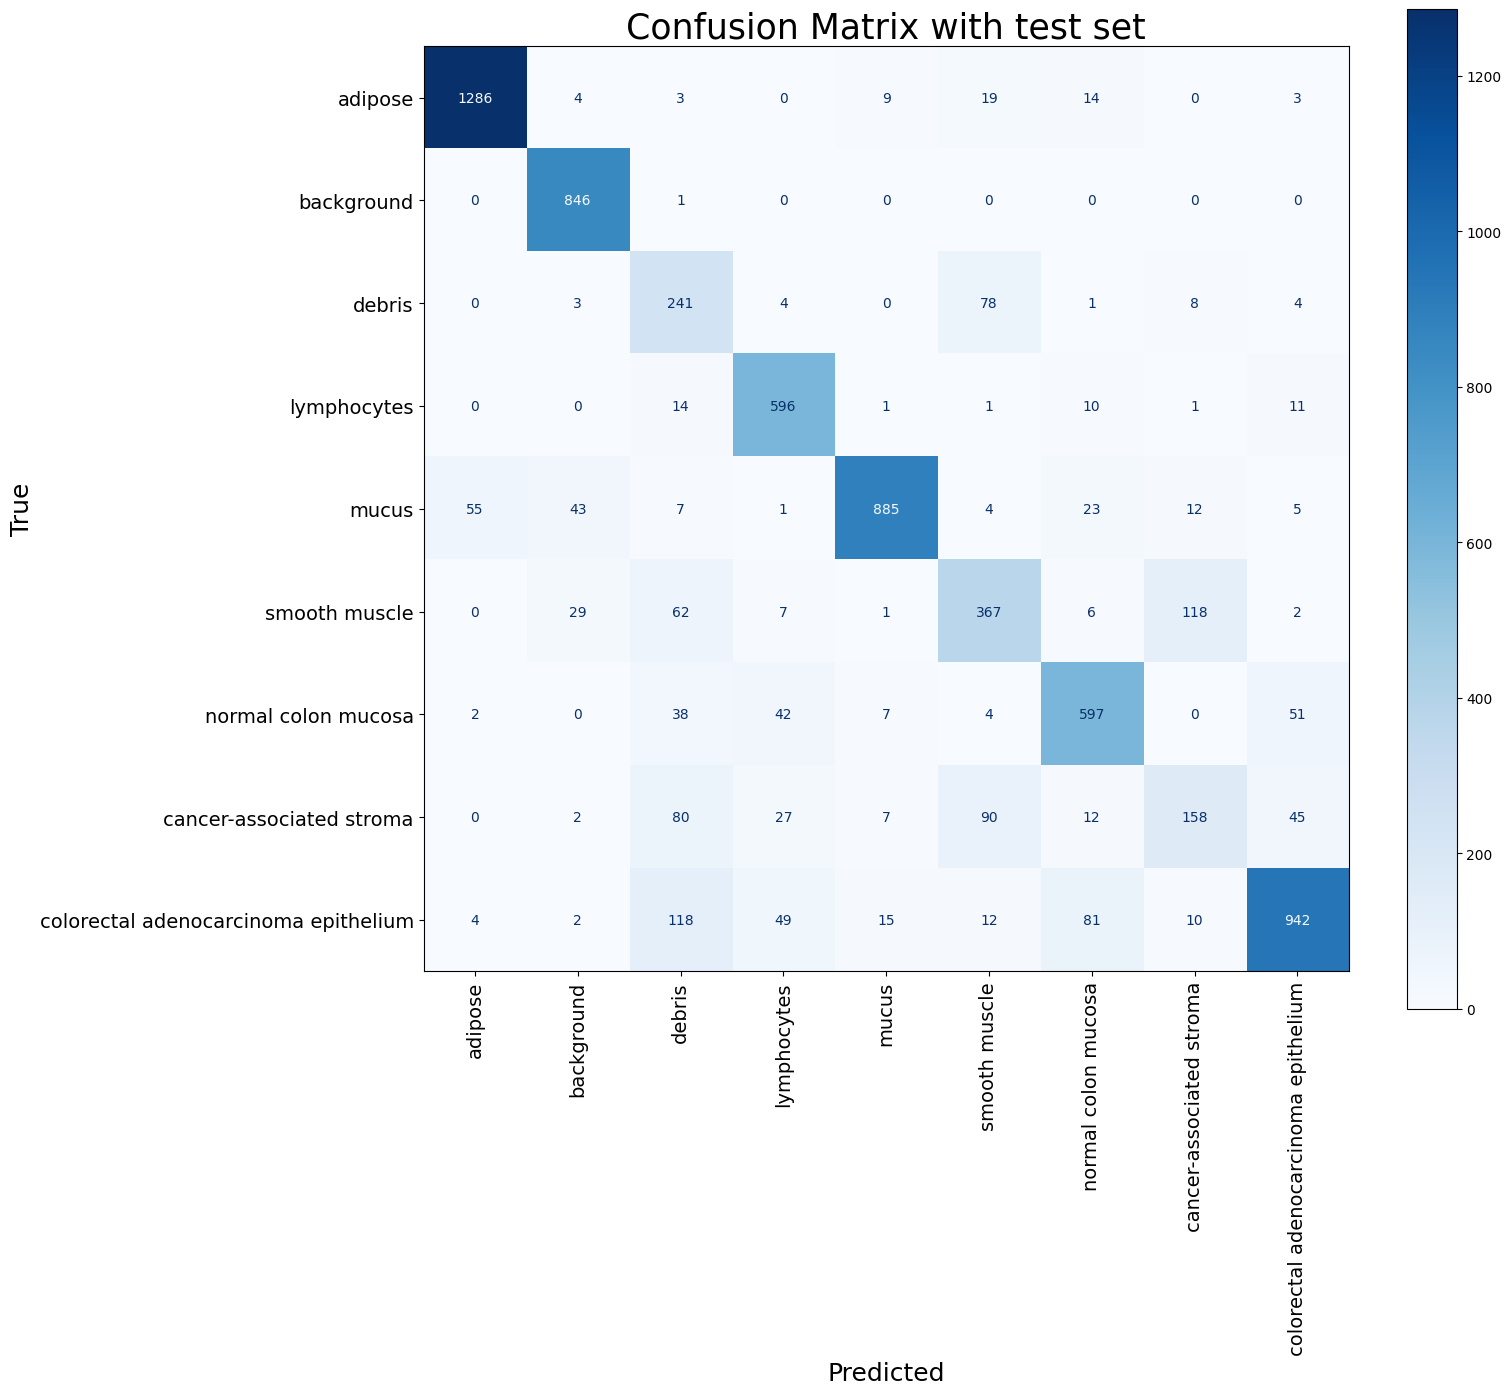

In [49]:
mc = plot_confusion_matrix(resnet18, test_loader_resnet, title="Confusion Matrix with test set", labels_names=labels_names)


(b) fine-tune the entire network. Report both results.

Epoch 5/10 — train_acc: 0.959, val_acc: 0.950
Epoch 10/10 — train_acc: 0.985, val_acc: 0.964


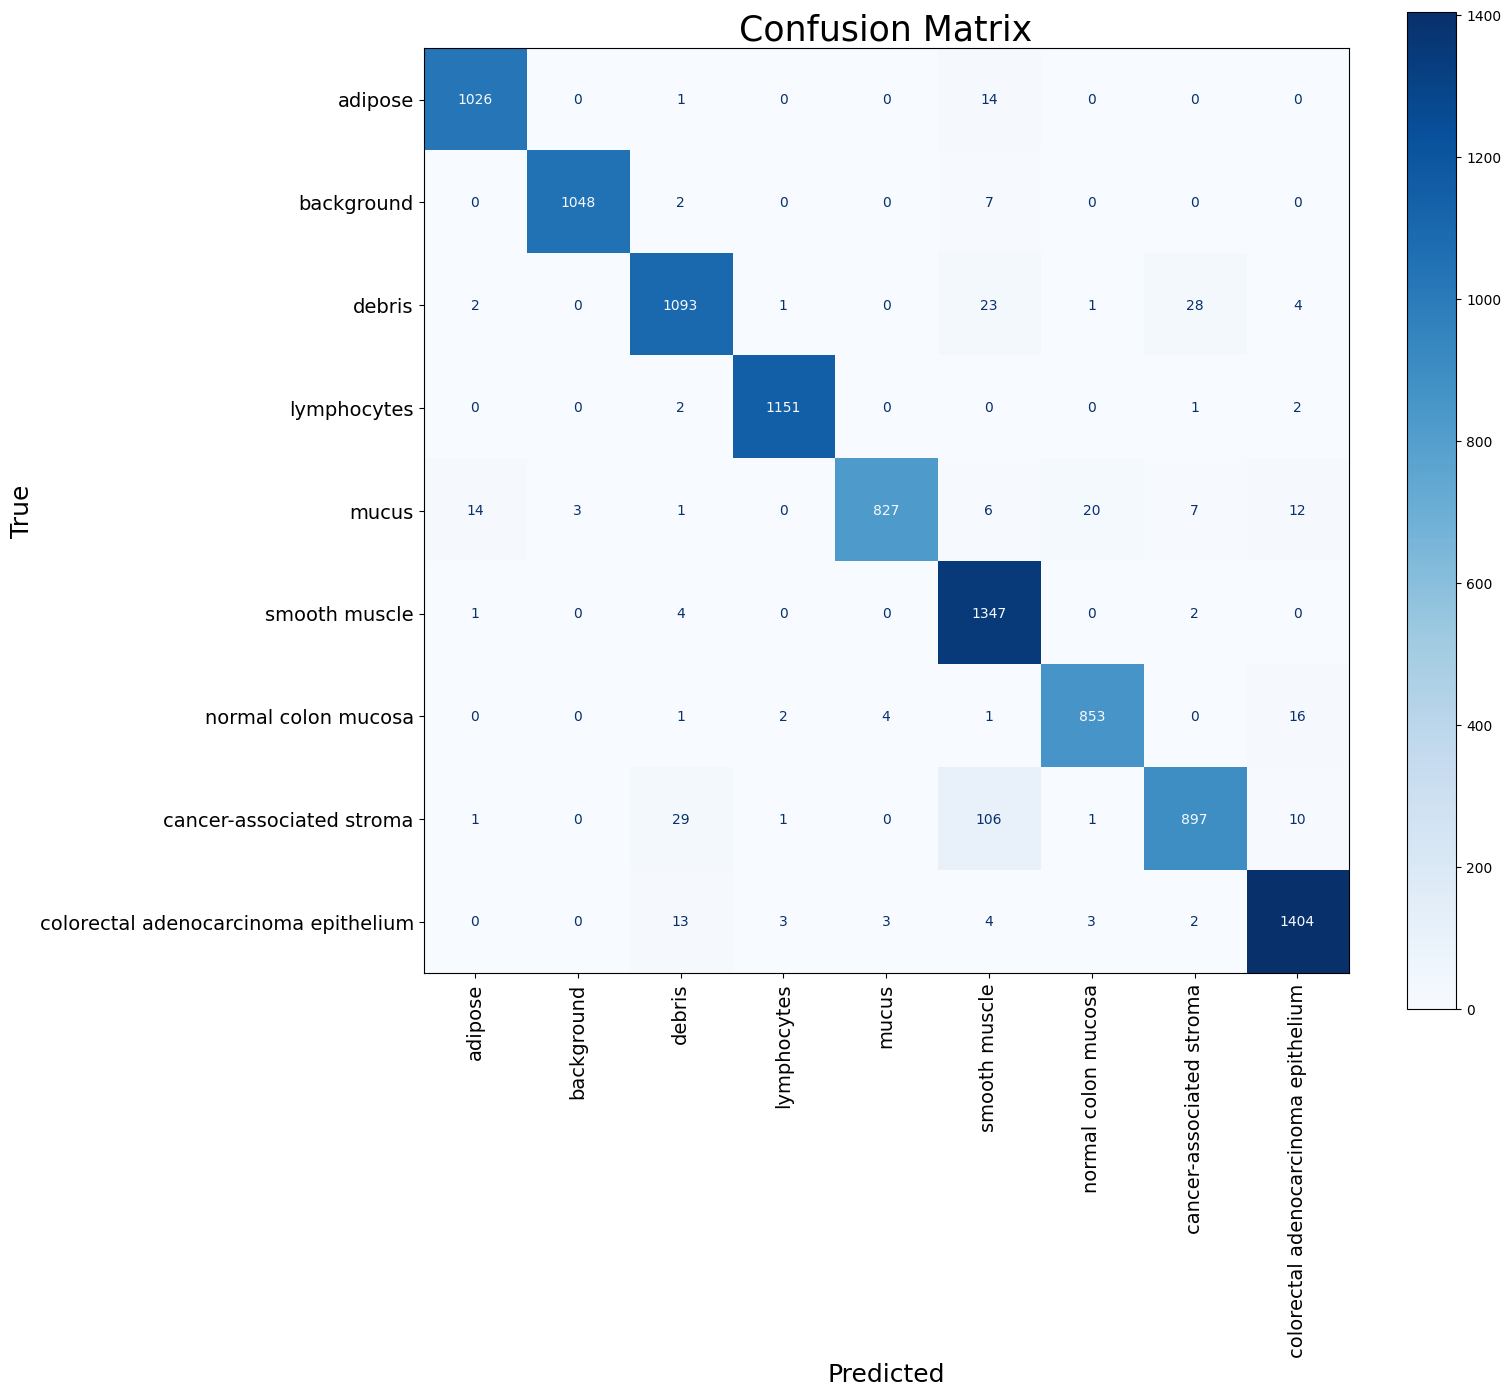

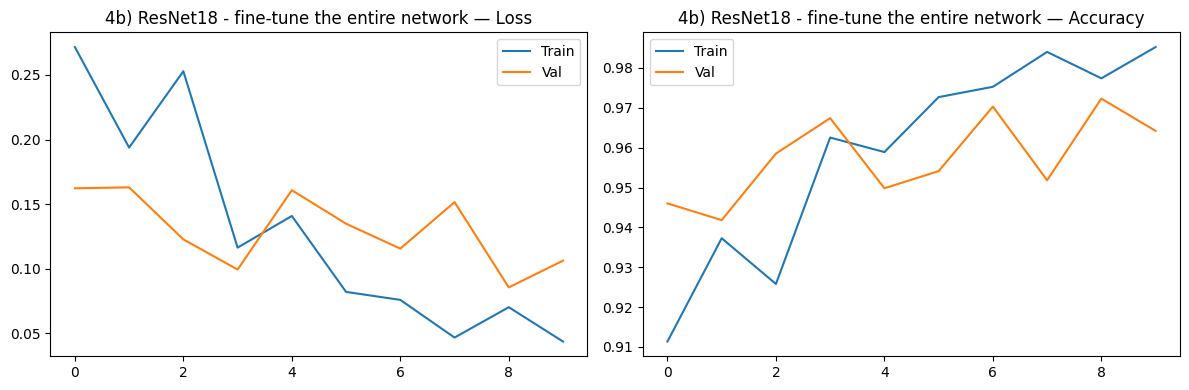

In [50]:
# fine-tune the entire network. Report both results.
for param in resnet18.parameters():
    param.requires_grad = True
optimizer_full = optim.Adam(resnet18.parameters(), lr=1e-4)
scheduler_resnet = optim.lr_scheduler.StepLR(optimizer_full, step_size=10, gamma=0.5)
history_resnet_b = train_model(resnet18, train_loader_resnet, val_loader_resnet, epochs=10, lr=1e-3, labels_names=labels_names)
plot_history(history_resnet_b, title="4b) ResNet18 - fine-tune the entire network")

In [51]:
# Test evaluation
test_loss_resnet18, test_acc_resnet18, preds_resnet18, labels_resnet18 = evaluate(resnet18, test_loader_resnet, criterion, device)
print(f"\nResnet Full Finetune Test Accuracy: {test_acc_resnet18:.2f}%")


Resnet Full Finetune Test Accuracy: 81.24%


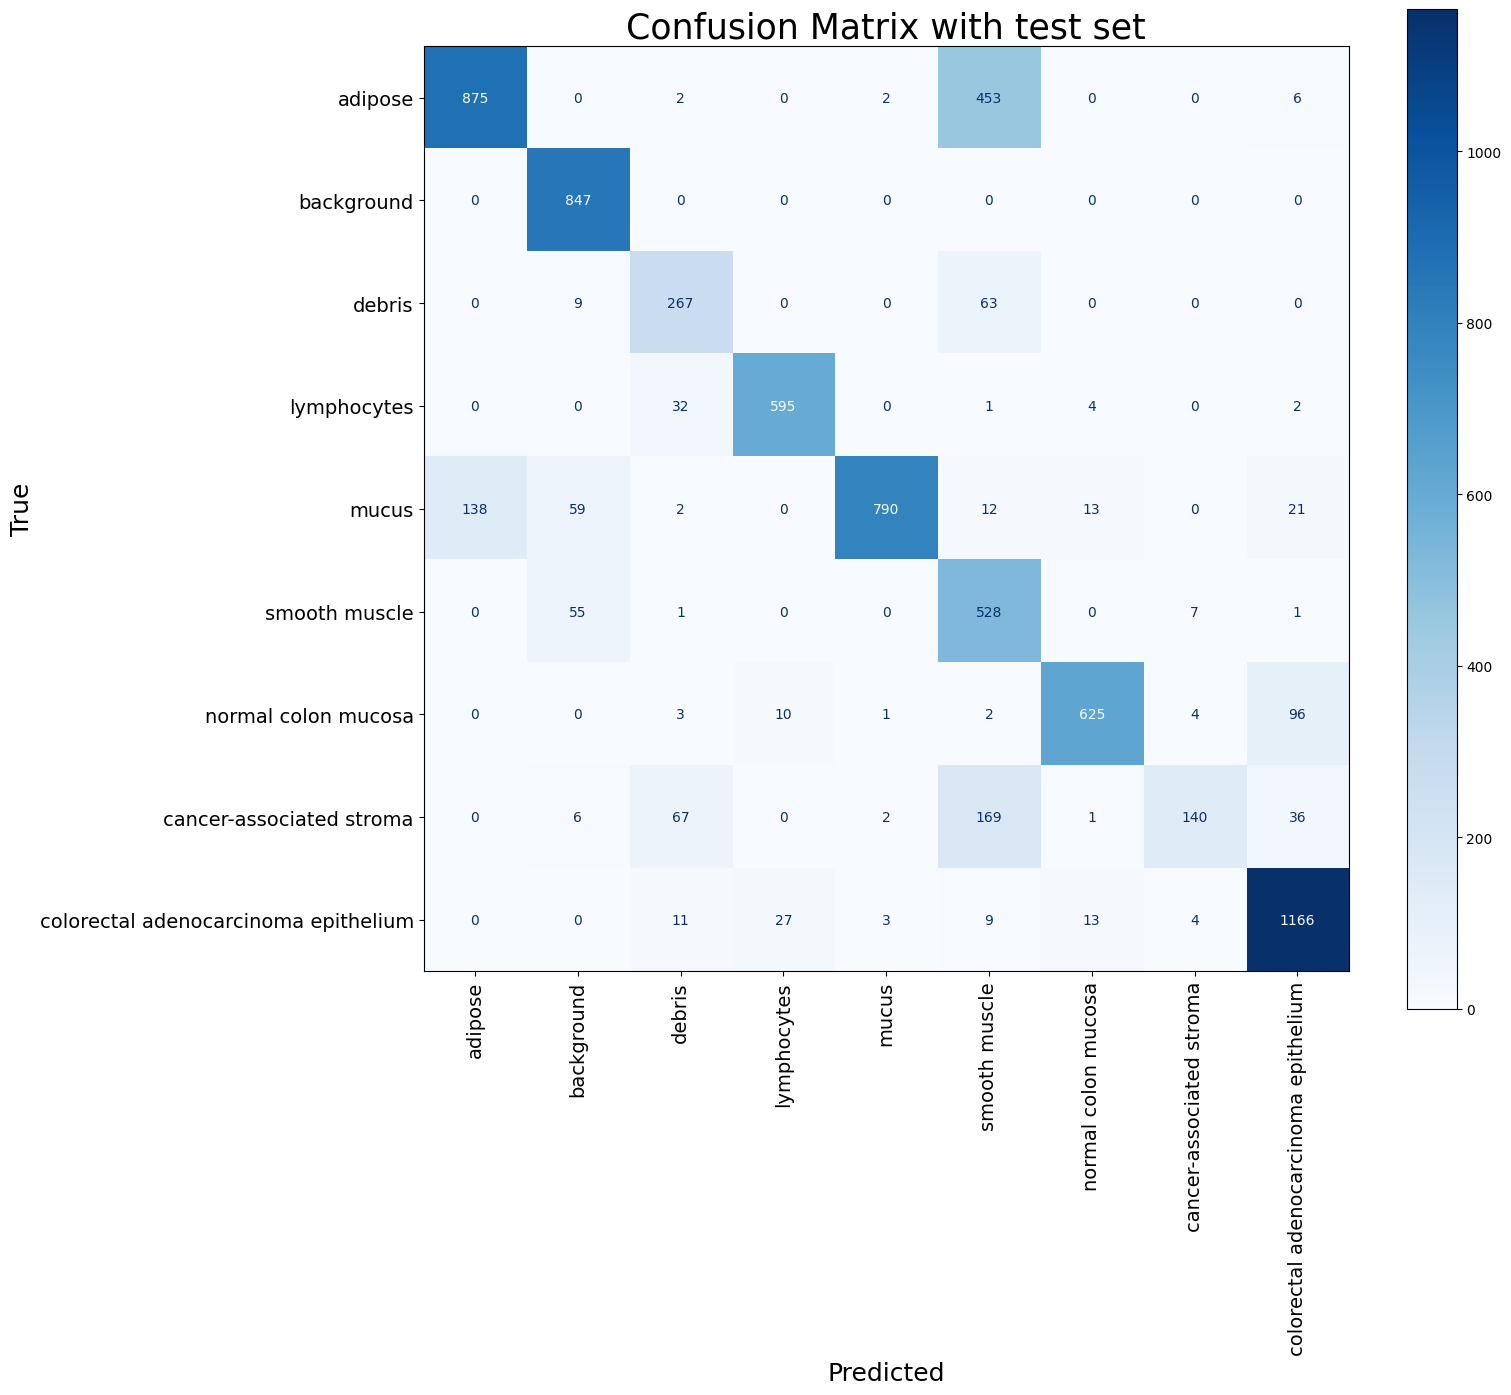

In [52]:
mc = plot_confusion_matrix(resnet18, test_loader_resnet, title="Confusion Matrix with test set", labels_names=labels_names)


#### Q4.2 — 8x upscaling consequence:
The 8x upscale (28→224) with bilinear interpolation creates blurry, artifactually smooth images.
The model "sees" interpolated pixel values that don't represent real tissue detail — it's like
zooming into a low-res photo. This can introduce false textures.
Alternative: Use a smaller input size (e.g., 96x96 or 128x128) and modify the first conv layer
stride, or use adaptive average pooling to handle arbitrary sizes.

#### Q4.3 — Transfer learning explanation:
The claim is incorrect — ImageNet does NOT contain medical/histology images.
Transfer learning works because early layers of ResNet learn universal low-level features:
edges, textures, color gradients, and simple shapes. These features (Gabor-like filters,
color blobs, corner detectors) are useful for ANY image domain. Only the deeper layers
learn domain-specific features, which is why fine-tuning the whole network helps.
""")


## 5) Vision Transformer from Scratch

In this section, we implement a Vision Transformer (ViT) from scratch to classify PathMNIST images by dividing each image into patches, embedding them into a sequence of tokens, and processing them with self-attention layers. Unlike convolutional networks, this architecture models relationships between image regions globally, and the final classification is performed using the output of a learnable CLS token enriched with positional embeddings.

In [53]:

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, n_patches_h, n_patches_w)
        x = x.flatten(2).transpose(1, 2)  # (B, n_patches, embed_dim)
        return x


class VisionTransformer(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=3, n_classes=9,
                 embed_dim=128, n_heads=4, n_layers=4, mlp_dim=256, dropout=0.1,
                 use_pos_embed=True):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.use_pos_embed = use_pos_embed
        if use_pos_embed:
            self.pos_embed = nn.Parameter(torch.randn(1, n_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=mlp_dim,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)  # (B, n_patches, embed_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, n_patches+1, embed_dim)
        if self.use_pos_embed:
            x = x + self.pos_embed
        x = self.dropout(x)
        x = self.transformer(x)
        x = self.norm(x[:, 0])  # CLS token
        x = self.head(x)
        return x

We choose a patch size of 7 so that each 28×28 image is divided into 16 patches, which keeps the sequence length small and manageable. The embedding dimension is set to 128 to provide a sufficiently rich feature representation without making the model too heavy. We use 4 attention heads so that the model can learn different relationships between patches in parallel. The transformer contains 4 encoder layers, which gives enough capacity to model global interactions while remaining suitable for training from scratch on this dataset. The MLP dimension is set to 256 to provide additional nonlinearity inside each transformer block, and a dropout rate of 0.1 is used to reduce overfitting.

Epoch 5/30 — train_acc: 0.854, val_acc: 0.880
Epoch 10/30 — train_acc: 0.896, val_acc: 0.898
Epoch 15/30 — train_acc: 0.913, val_acc: 0.914
Epoch 20/30 — train_acc: 0.926, val_acc: 0.926
Epoch 25/30 — train_acc: 0.934, val_acc: 0.928
Epoch 30/30 — train_acc: 0.938, val_acc: 0.936


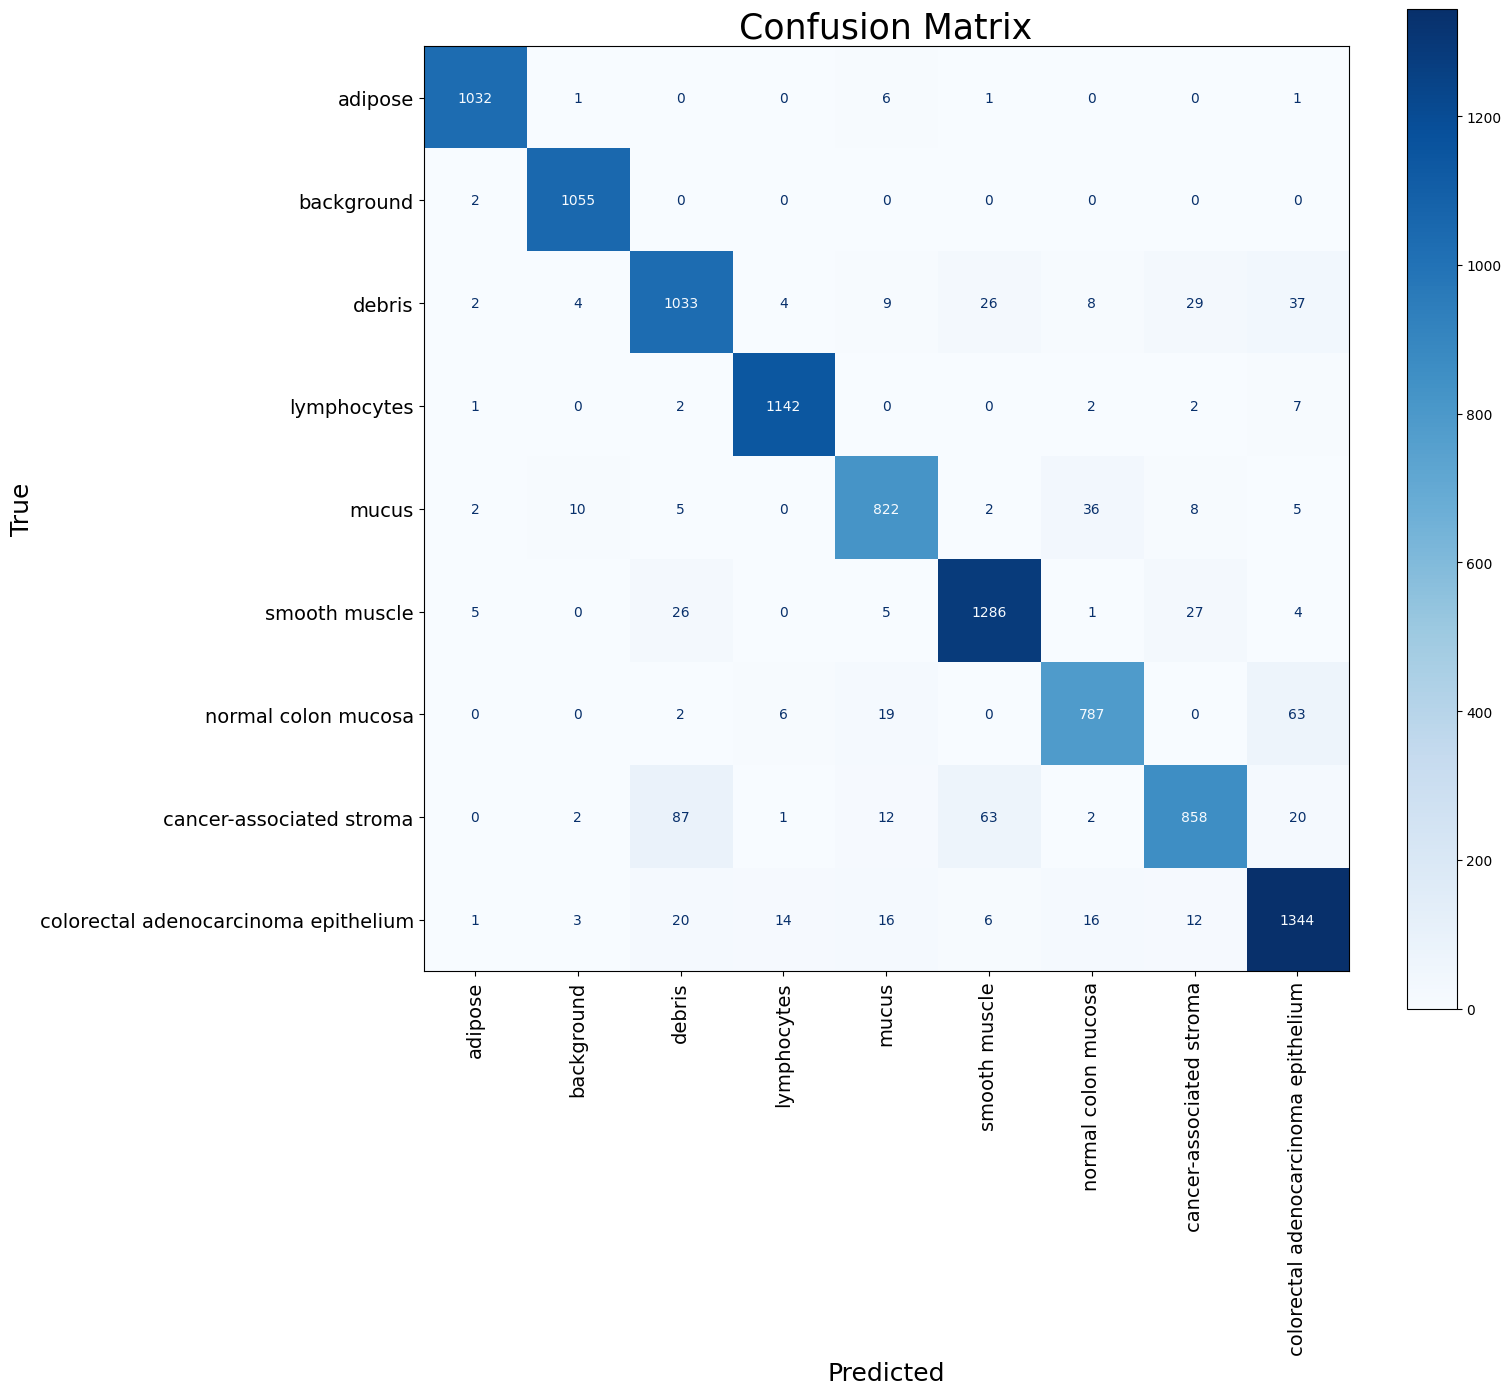

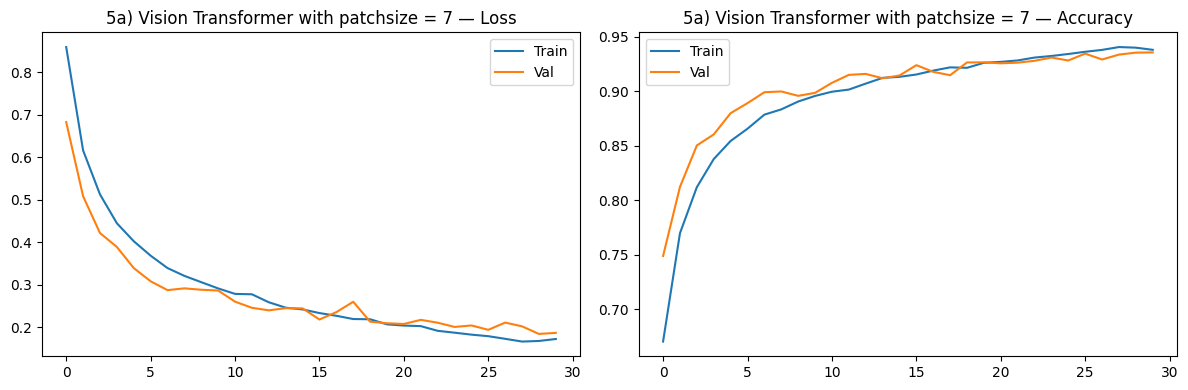

In [54]:
vit7 = VisionTransformer(
    img_size=28, patch_size=7, n_classes=num_classes,
    embed_dim=128, n_heads=4, n_layers=4, mlp_dim=256, dropout=0.1,
    use_pos_embed=True
).to(device)
history_vit7 = train_model(vit7, train_loader, val_loader, epochs=30, lr=1e-3, labels_names=labels_names)
plot_history(history_vit7, title="5a) Vision Transformer with patchsize = 7")

In [55]:
# Test evaluation
test_loss_vit7, test_acc_vit7, preds_vit7, labels_vit7 = evaluate(vit7, test_loader, criterion, device)
print(f"\nViT 7 Test Accuracy: {test_acc_vit7:.2f}%")


ViT 7 Test Accuracy: 78.75%


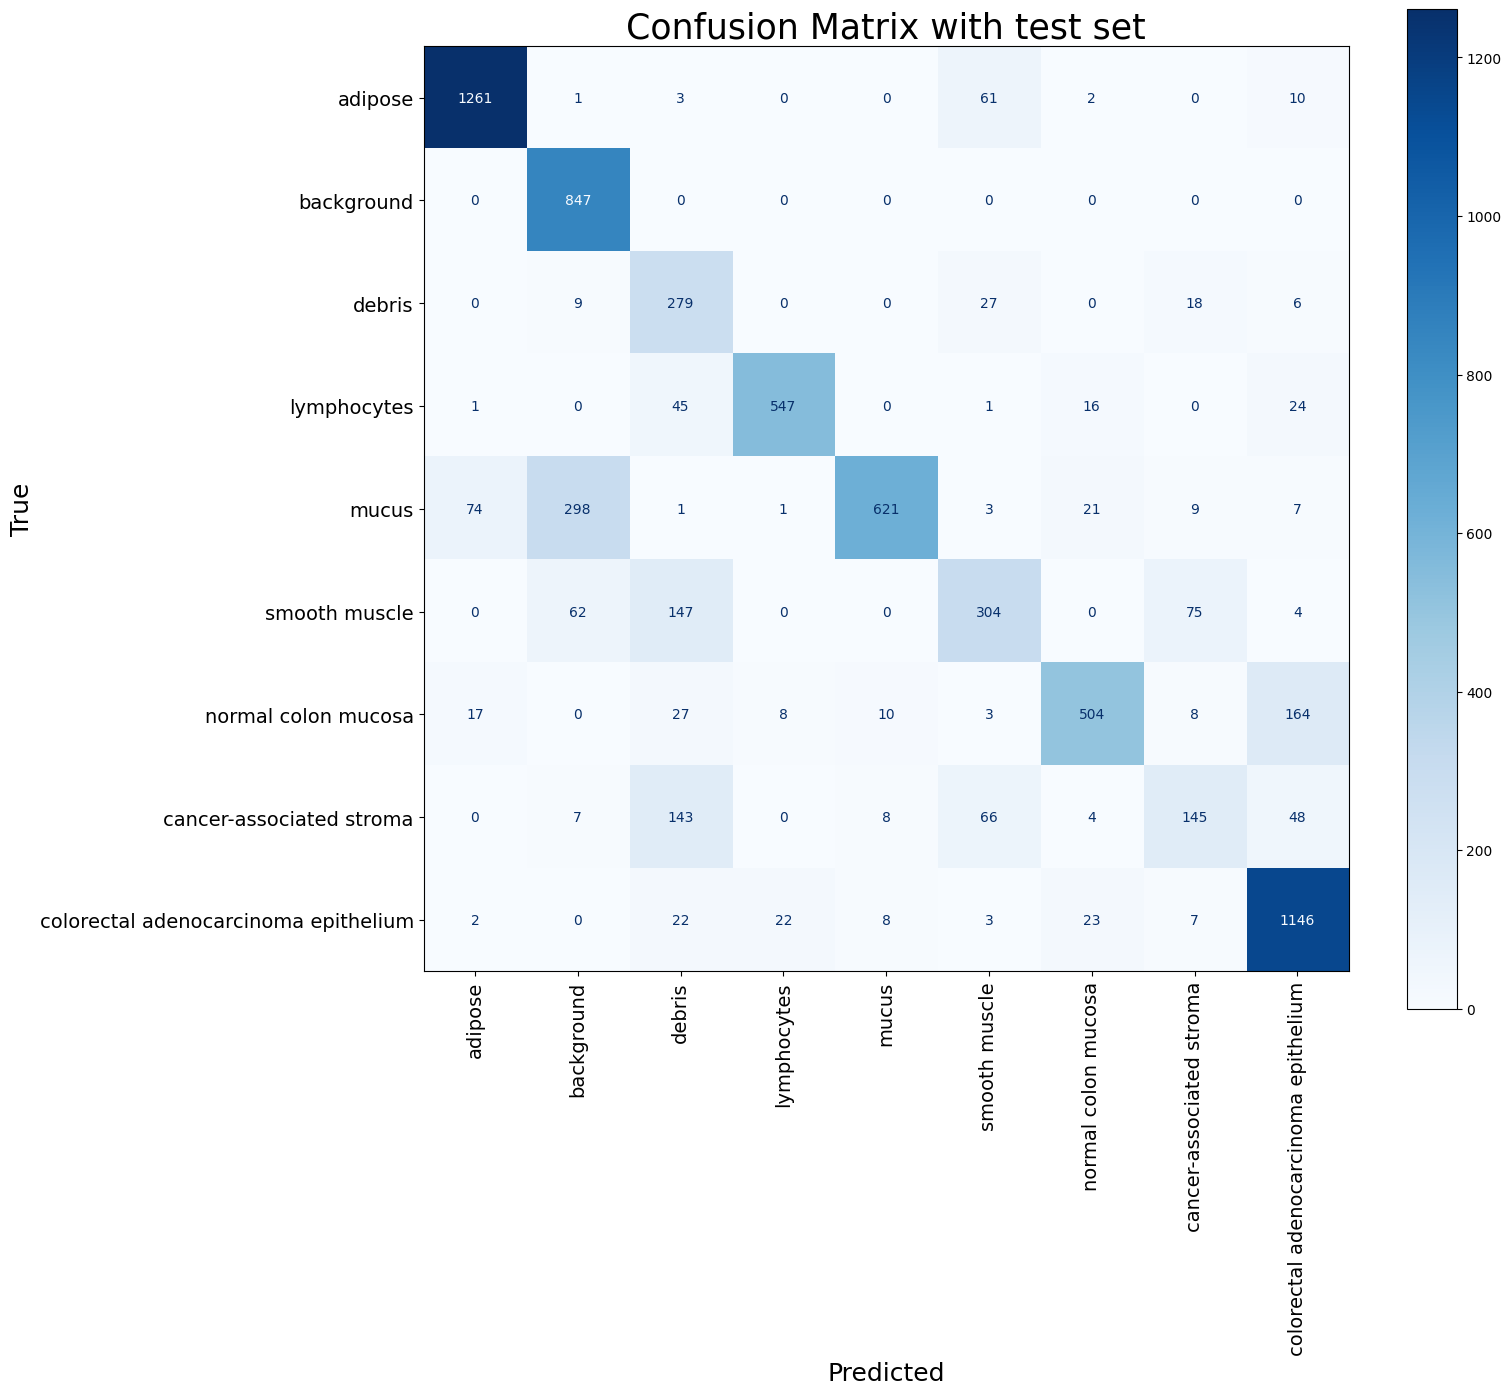

In [56]:
mc = plot_confusion_matrix(vit7, test_loader, title="Confusion Matrix with test set", labels_names=labels_names)

Epoch 5/30 — train_acc: 0.749, val_acc: 0.776
Epoch 10/30 — train_acc: 0.793, val_acc: 0.803
Epoch 15/30 — train_acc: 0.821, val_acc: 0.827
Epoch 20/30 — train_acc: 0.844, val_acc: 0.840
Epoch 25/30 — train_acc: 0.852, val_acc: 0.849
Epoch 30/30 — train_acc: 0.867, val_acc: 0.856


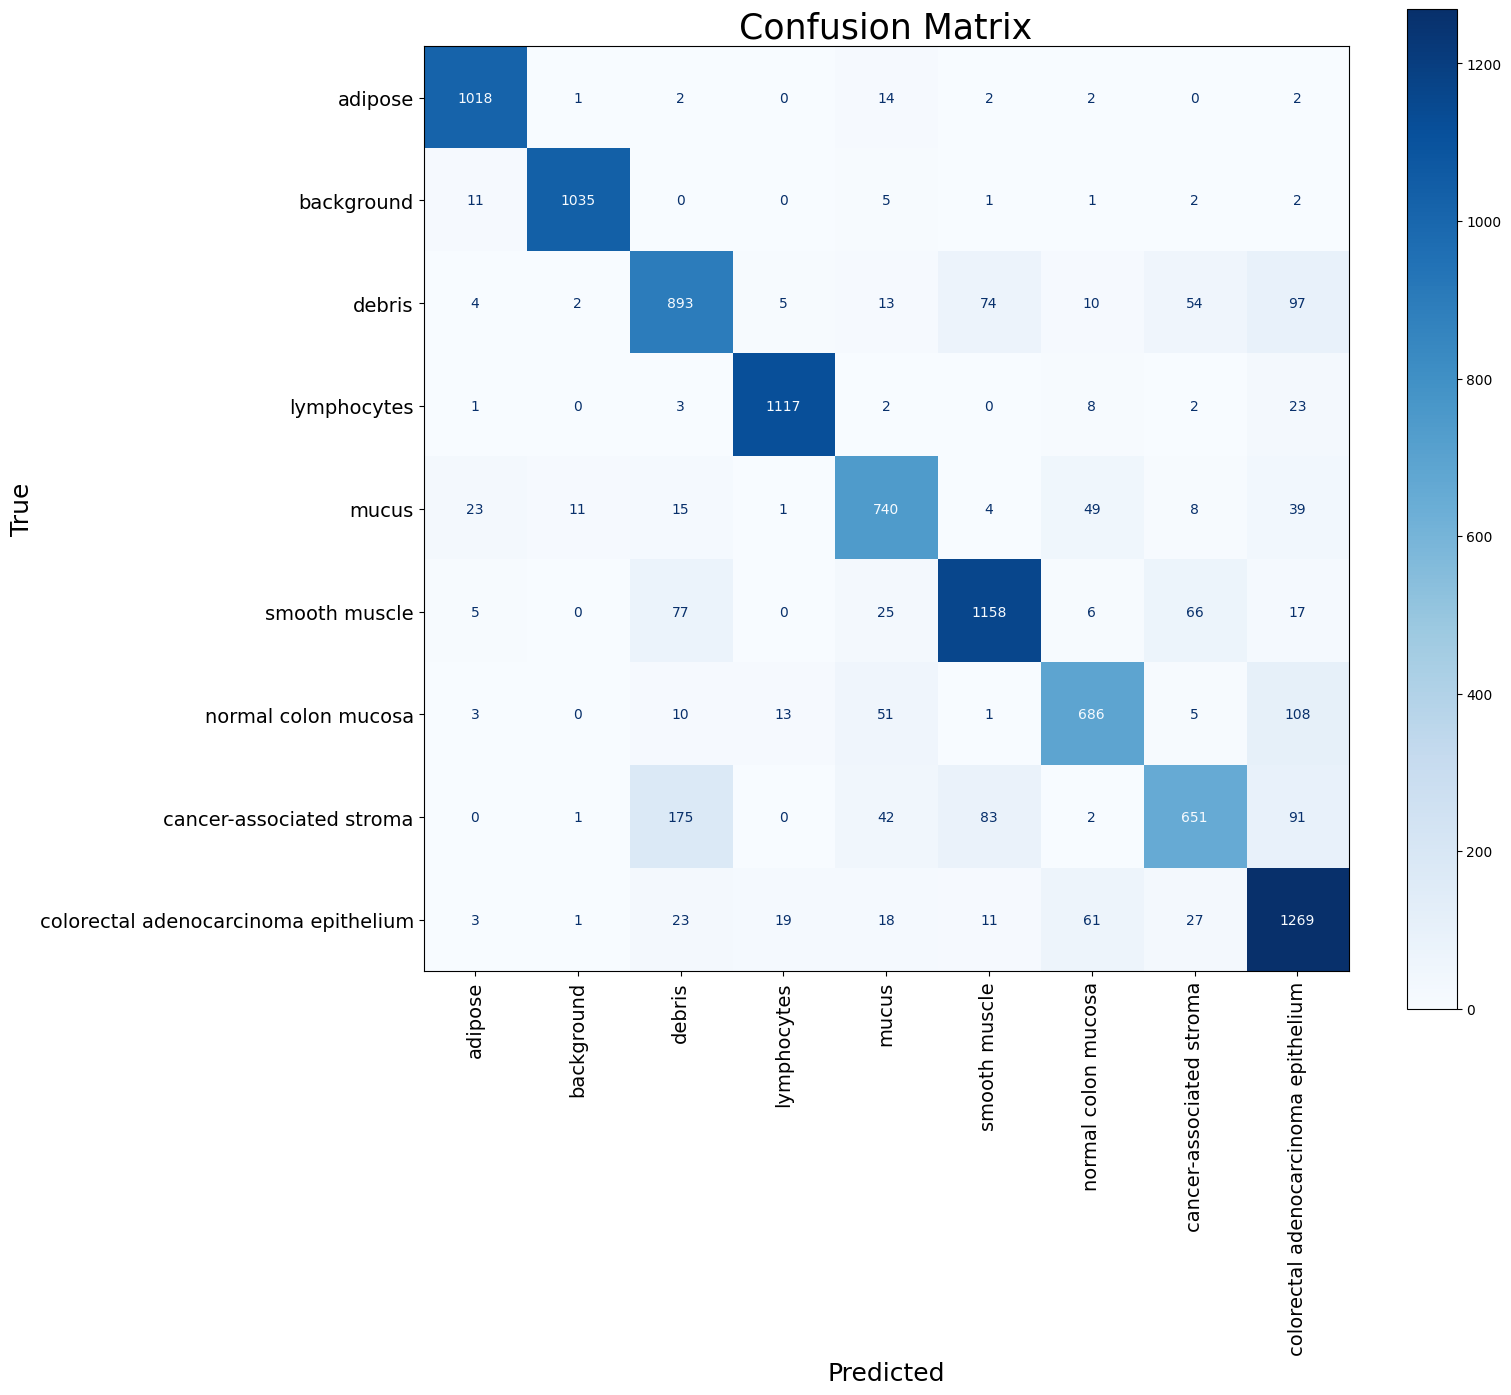

In [57]:
vit14 = VisionTransformer(
    img_size=28, patch_size=14, n_classes=num_classes,
    embed_dim=128, n_heads=4, n_layers=4, mlp_dim=256, dropout=0.1,
    use_pos_embed=True
).to(device)
history_vit14 = train_model(vit14, train_loader, val_loader, epochs=30, lr=1e-3, labels_names=labels_names)

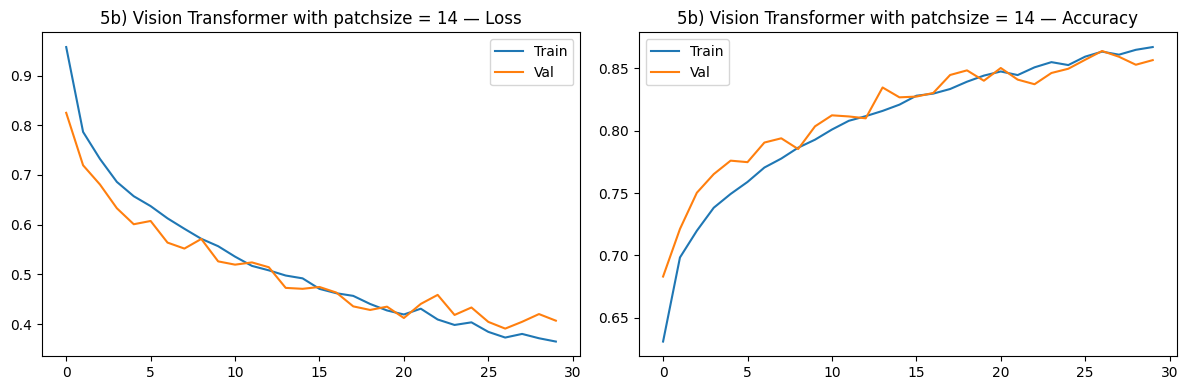

In [58]:
plot_history(history_vit14, title="5b) Vision Transformer with patchsize = 14")

In [59]:
# Test evaluation
test_loss_vit14, test_acc_vit14, preds_vit14, labels_vit14 = evaluate(vit14, test_loader, criterion, device)
print(f"\nViT 14 Test Accuracy: {test_acc_vit14:.2f}%")



ViT 14 Test Accuracy: 70.63%


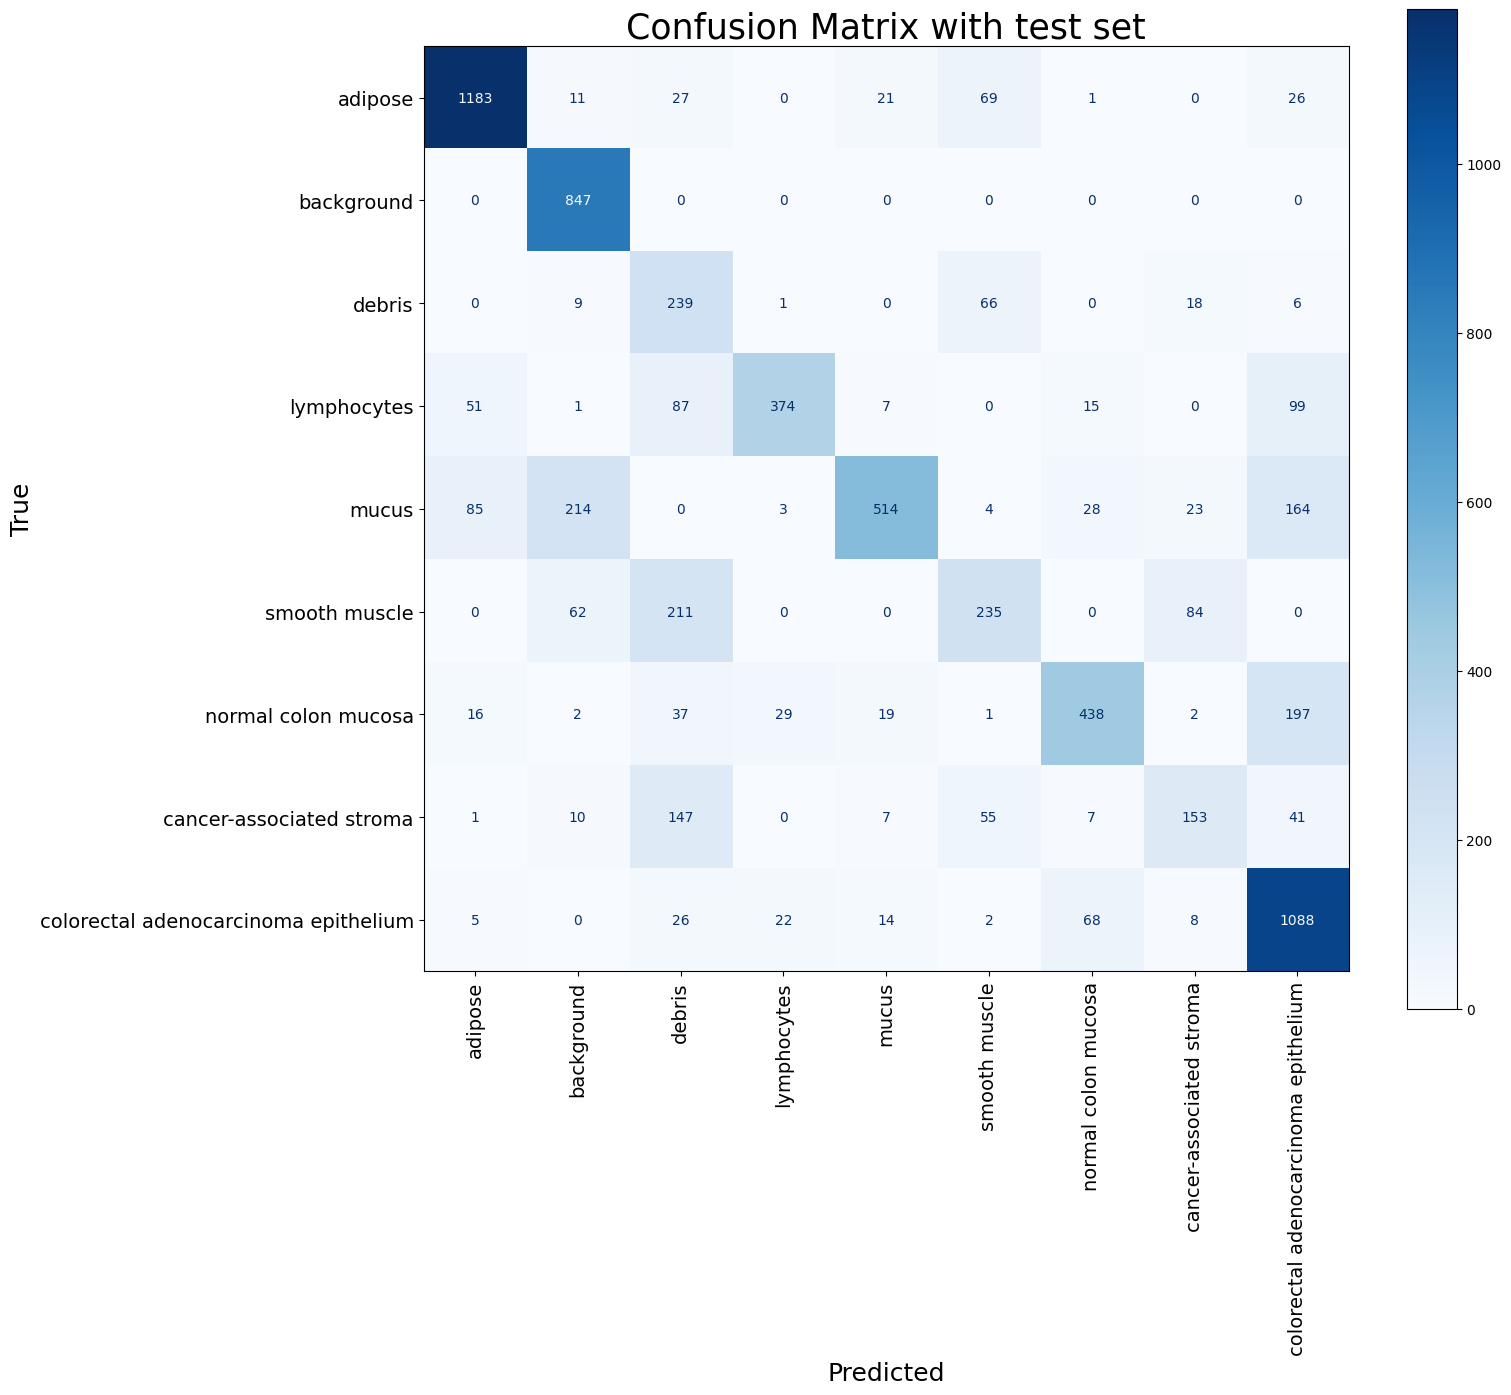

In [60]:
mc = plot_confusion_matrix(vit14, test_loader, title="Confusion Matrix with test set", labels_names=labels_names)

### Q5.2 – Effect of removing positional embeddings

Epoch 5/30 — train_acc: 0.887, val_acc: 0.901
Epoch 10/30 — train_acc: 0.916, val_acc: 0.917
Epoch 15/30 — train_acc: 0.932, val_acc: 0.929
Epoch 20/30 — train_acc: 0.939, val_acc: 0.927
Epoch 25/30 — train_acc: 0.946, val_acc: 0.944
Epoch 30/30 — train_acc: 0.951, val_acc: 0.948


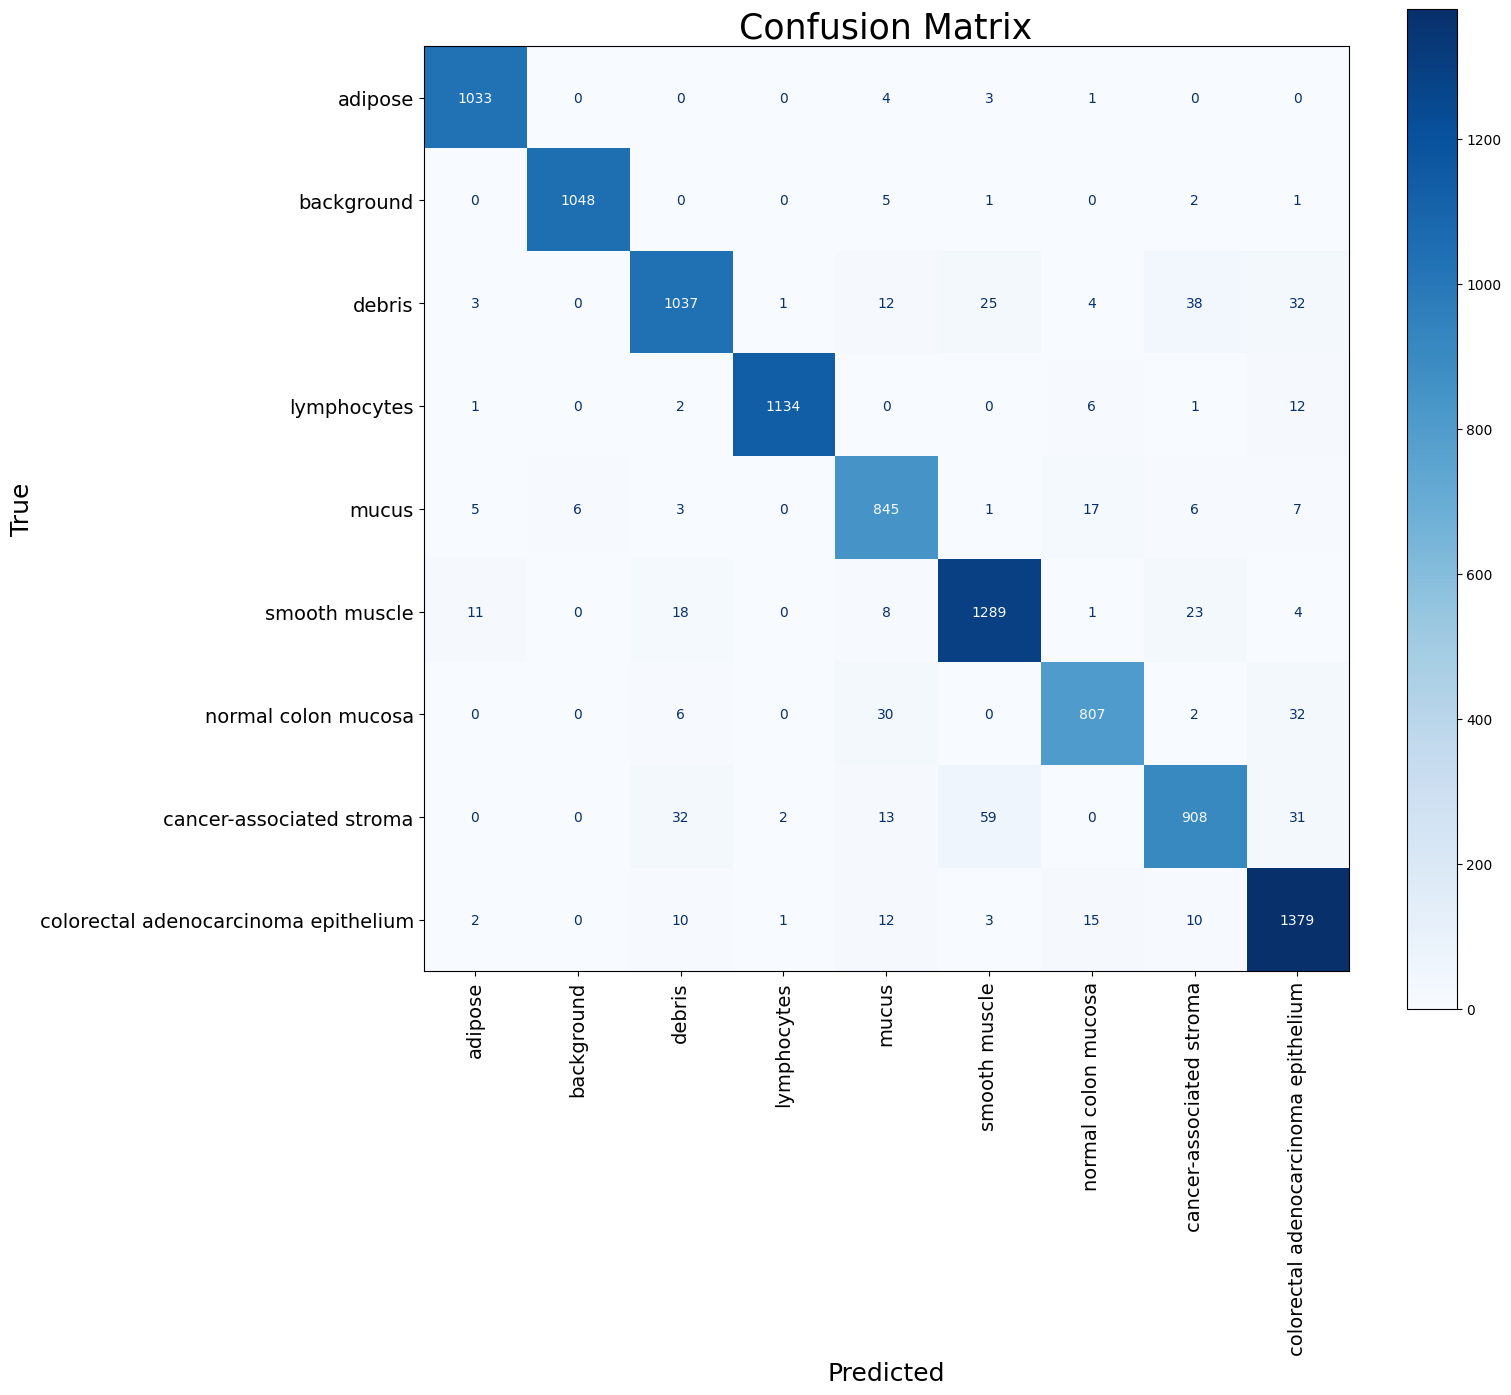

In [61]:
vit_nopos = VisionTransformer(
    img_size=28, patch_size=7, n_classes=num_classes,
    embed_dim=128, n_heads=4, n_layers=4, mlp_dim=256, dropout=0.1,
    use_pos_embed=False
).to(device)
history_vit_nopos = train_model(vit_nopos, train_loader, val_loader, epochs=30, lr=1e-3, labels_names=labels_names)

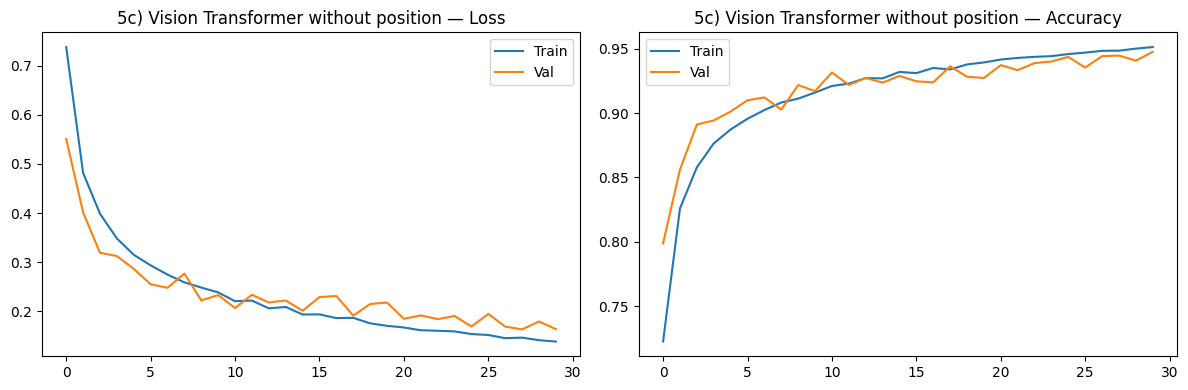

In [62]:
plot_history(history_vit_nopos, title="5c) Vision Transformer without position")

In [63]:
# Test evaluation
test_loss_vit_nopos, test_acc_vit_nopos, preds_vit_nopos, labels_vit_nopos = evaluate(vit_nopos, test_loader, criterion, device)
print(f"\nViT nopos Test Accuracy: {test_acc_vit_nopos:.2f}%")


ViT nopos Test Accuracy: 80.89%


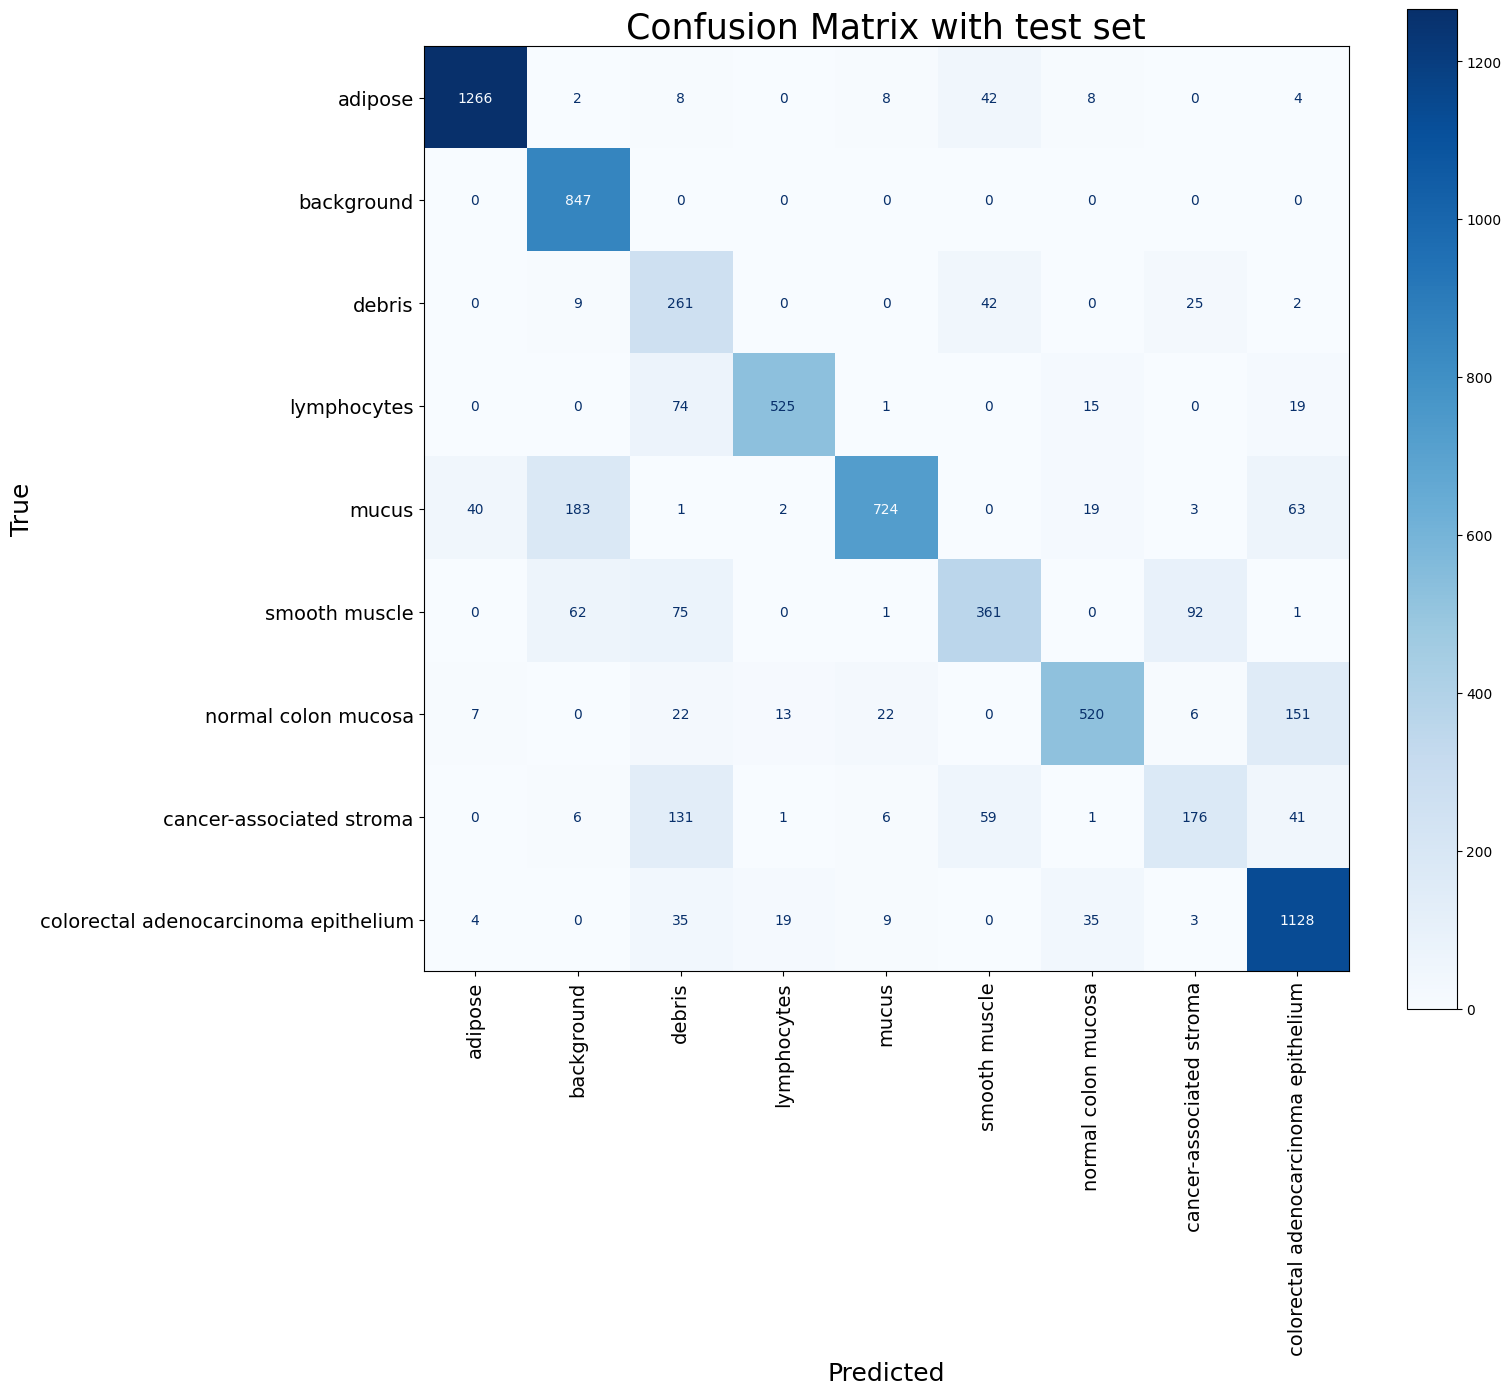

In [64]:
mc = plot_confusion_matrix(vit_nopos, test_loader, title="Confusion Matrix with test set", labels_names=labels_names)

Although positional embeddings are theoretically essential in Vision Transformers to encode spatial information, we observed that removing them led to better performance.

This unexpected result can be explained by the low resolution of the input images (28×28), which limits the amount of meaningful spatial structure available. In this setting, the task relies more on texture and local patterns than on precise spatial relationships.

As a result, treating the image as an unordered set of patches does not significantly degrade performance and may even simplify the learning process. Additionally, positional embeddings may introduce noise or be poorly learned when the dataset is limited, which can negatively impact the model.

Therefore, in this specific context, removing positional information acts as a form of implicit regularization and leads to better generalization.

### Q5.3 – Compare the number of parameters to the CNN

In [65]:
total_params_vit = sum(p.numel() for p in vit7.parameters() if p.requires_grad)
print(total_params_vit)

552585


In [66]:
dif_param = total_params - total_params_vit
print(abs(dif_param))

115040


Parameter comparison:
  CNN parameters: 437,545
  ViT parameters: 552,585
  Ratio: ViT has 1.3x more parameters

  ViTs typically need more data than CNNs to train effectively because they lack the
  inductive biases of convolutions (translation equivariance, locality). With only ~89k
  training images at 28x28, the CNN's built-in spatial priors give it an advantage.

## 6) Grad-CAM Interpretability
Deep neural networks are often considered as "black box" models.
Grad-CAM helps us understand which regions of an image influence the prediction of the CNN.

Grad-CAM generates a heatmap that highlights the most important areas used by the model when making a prediction.

In this section, we apply Grad-CAM to visualize the regions that the CNN focuses on for some test images.

In [67]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=f6604ffd2cf612e12371c27544c3d01ff1d3eefd71af1805fb5b5a154d0aa41c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Target layer selection:

Grad-CAM works on convolutional feature maps.
We therefore select the last convolution layer of the CNN as the target layer.

This layer contains high-level visual features learned by the model.

In [69]:
target_layer = cnn_aug.block3[2]

To better understand how the CNN makes its predictions, we visualize Grad-CAM explanations for several images per classes from the test set.

For each example, we show:

the original image
the Grad-CAM heatmap
the true label and predicted label

In [80]:
# Make sure gradients are enabled
for param in model.parameters():
    param.requires_grad = True

model.eval()

# Example: choose the LAST convolutional layer
# Replace this with the correct layer for your model
target_layer = None
for module in reversed(list(model.modules())):
    if isinstance(module, torch.nn.Conv2d):
        target_layer = module
        break

print("Target layer:", target_layer)

Target layer: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [81]:
class_images = [None] * num_classes
class_labels = [None] * num_classes

for i in range(len(test_dataset)):
    img, label = test_dataset[i]
    label = int(np.array(label).squeeze())

    if class_images[label] is None:
        class_images[label] = img
        class_labels[label] = label

    if all(x is not None for x in class_images):
        break

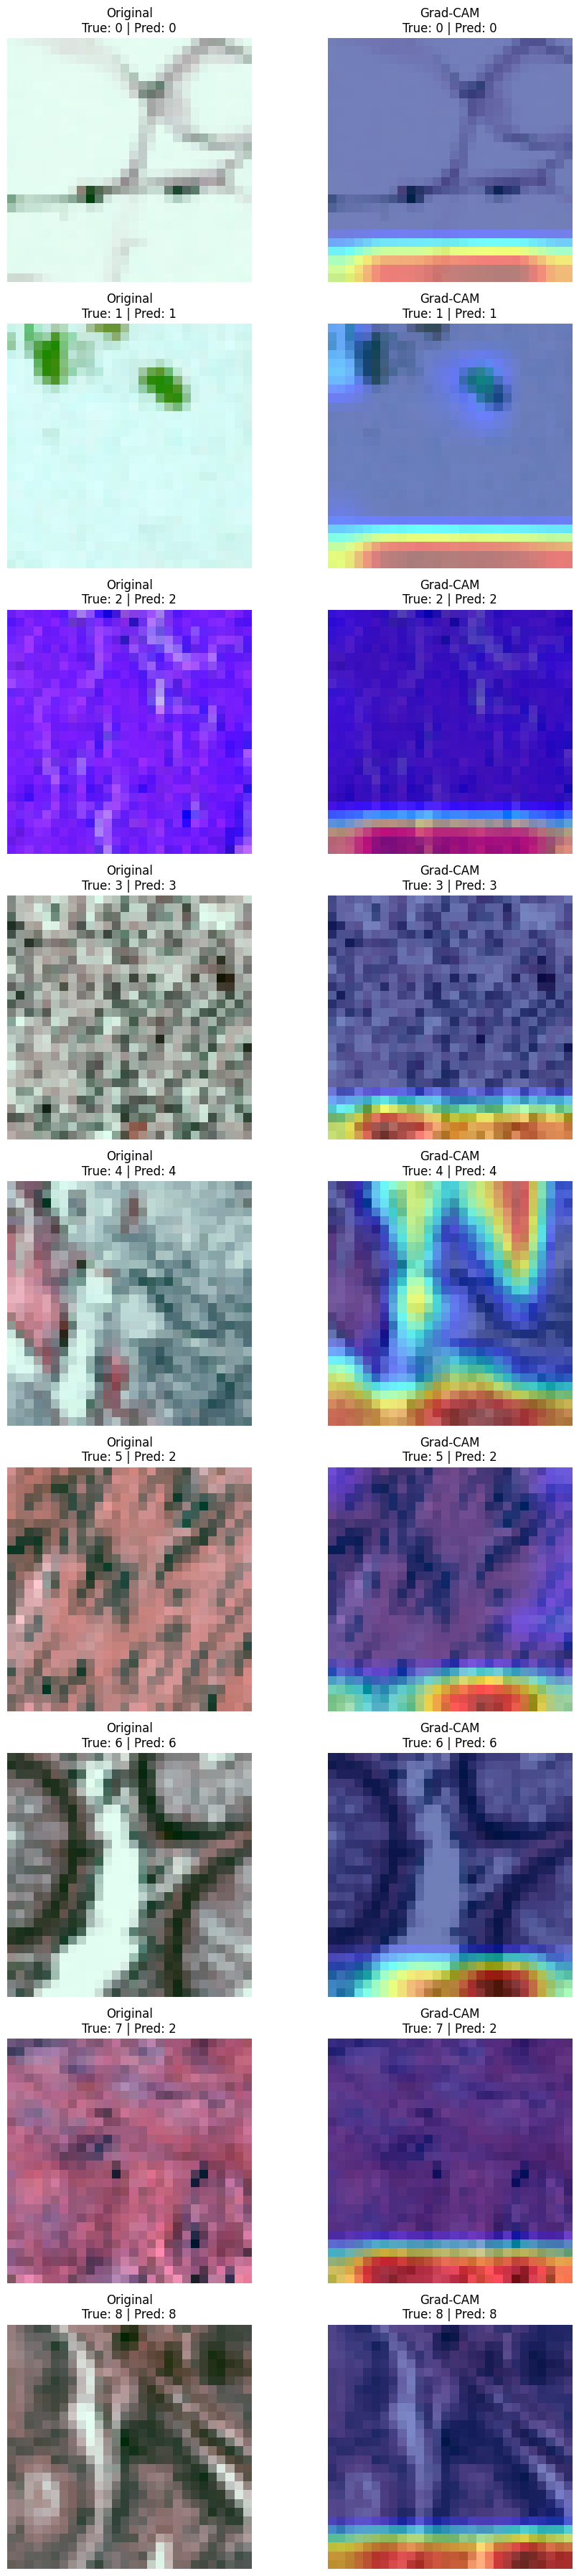

In [82]:
cam = GradCAM(model=model, target_layers=[target_layer])

plt.figure(figsize=(10, 4 * num_classes))

for cls in range(num_classes):
    img = class_images[cls]
    label = class_labels[cls]

    if img is None:
        continue

    input_tensor = img.unsqueeze(0).to(device)

    # Forward pass
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    # Grad-CAM target
    targets = [ClassifierOutputTarget(pred_class)]

    # Compute CAM
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # Convert image for display
    rgb_img = img.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.subplot(num_classes, 2, 2 * cls + 1)
    plt.imshow(rgb_img)
    plt.title(f"Original\nTrue: {label} | Pred: {pred_class}")
    plt.axis("off")

    plt.subplot(num_classes, 2, 2 * cls + 2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM\nTrue: {label} | Pred: {pred_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Q6.1 Grad-CAM Analysis (Tumor Epithelium vs Normal Mucosa):
For Tumor Epithelium, the heatmap typically highlights dense, clustered regions in the center
where tightly packed epithelial cells are present — the activation is concentrated and intense.
For Normal Mucosa, the heatmap tends to be more distributed, highlighting the glandular
structures and their boundaries, often with activation spread across regular, organized patterns
rather than a single dense cluster.

In [83]:
misclassified_img = None
misclassified_true = None
misclassified_pred = None

for i in range(len(test_dataset)):
    img, label = test_dataset[i]

    if torch.is_tensor(label):
        label = label.item()

    input_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred_class = output.argmax(dim=1).item()

    if pred_class != label:
        misclassified_img = img
        misclassified_true = label
        misclassified_pred = pred_class
        print(f"Misclassified sample found at index {i}")
        print(f"True class: {misclassified_true}, Predicted class: {misclassified_pred}")
        break

Misclassified sample found at index 4
True class: [4], Predicted class: 0


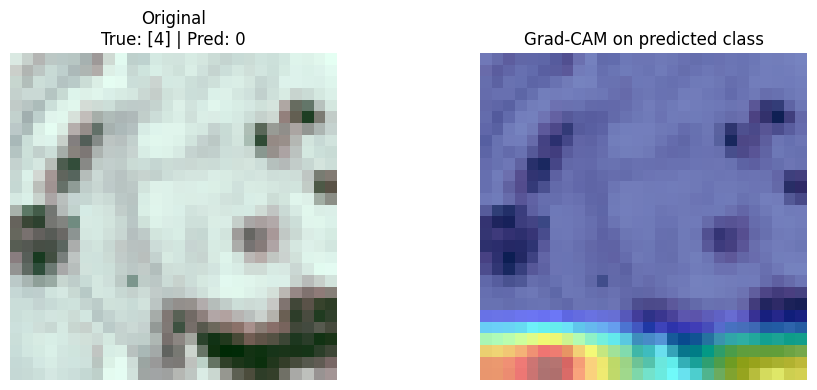

In [84]:
targets = [ClassifierOutputTarget(misclassified_pred)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# Convert image for display
rgb_img = misclassified_img.permute(1, 2, 0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title(f"Original\nTrue: {misclassified_true} | Pred: {misclassified_pred}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM on predicted class")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Q6.2 — Misclassified Example Analysis:
When comparing the Grad-CAM for the predicted vs. true class on a misclassified image,
the heatmaps often overlap significantly, suggesting the model found ambiguous features
that could belong to either class. The predicted class heatmap typically shows slightly
stronger activation in regions with shared visual properties between the two classes.

## 7 Final Comparison and Analysis



### 7.1) Summary Table

| Model                  | # Parameters | Test Accuracy (%) | Training Time (s) |
|------------------------|-------------|-------------------|-------------------|
| MLP                    | 1,370,121   | 64.14             | 339               |
| CNN (scratch)          | 437,545     | 89.09             | 1010              |
| ResNet-18 (fine-tuned) | 11,181,129  | 83.58             | 1233              |
| ViT (scratch)          | 552,585     | 80.09             | 1362              |

### 7.2) Per-class Analysis

This analysis highlights the most frequent class confusions in the model using the confusion matrix and per-class F1-scores, providing insights into visually and medically similar tissue patterns.

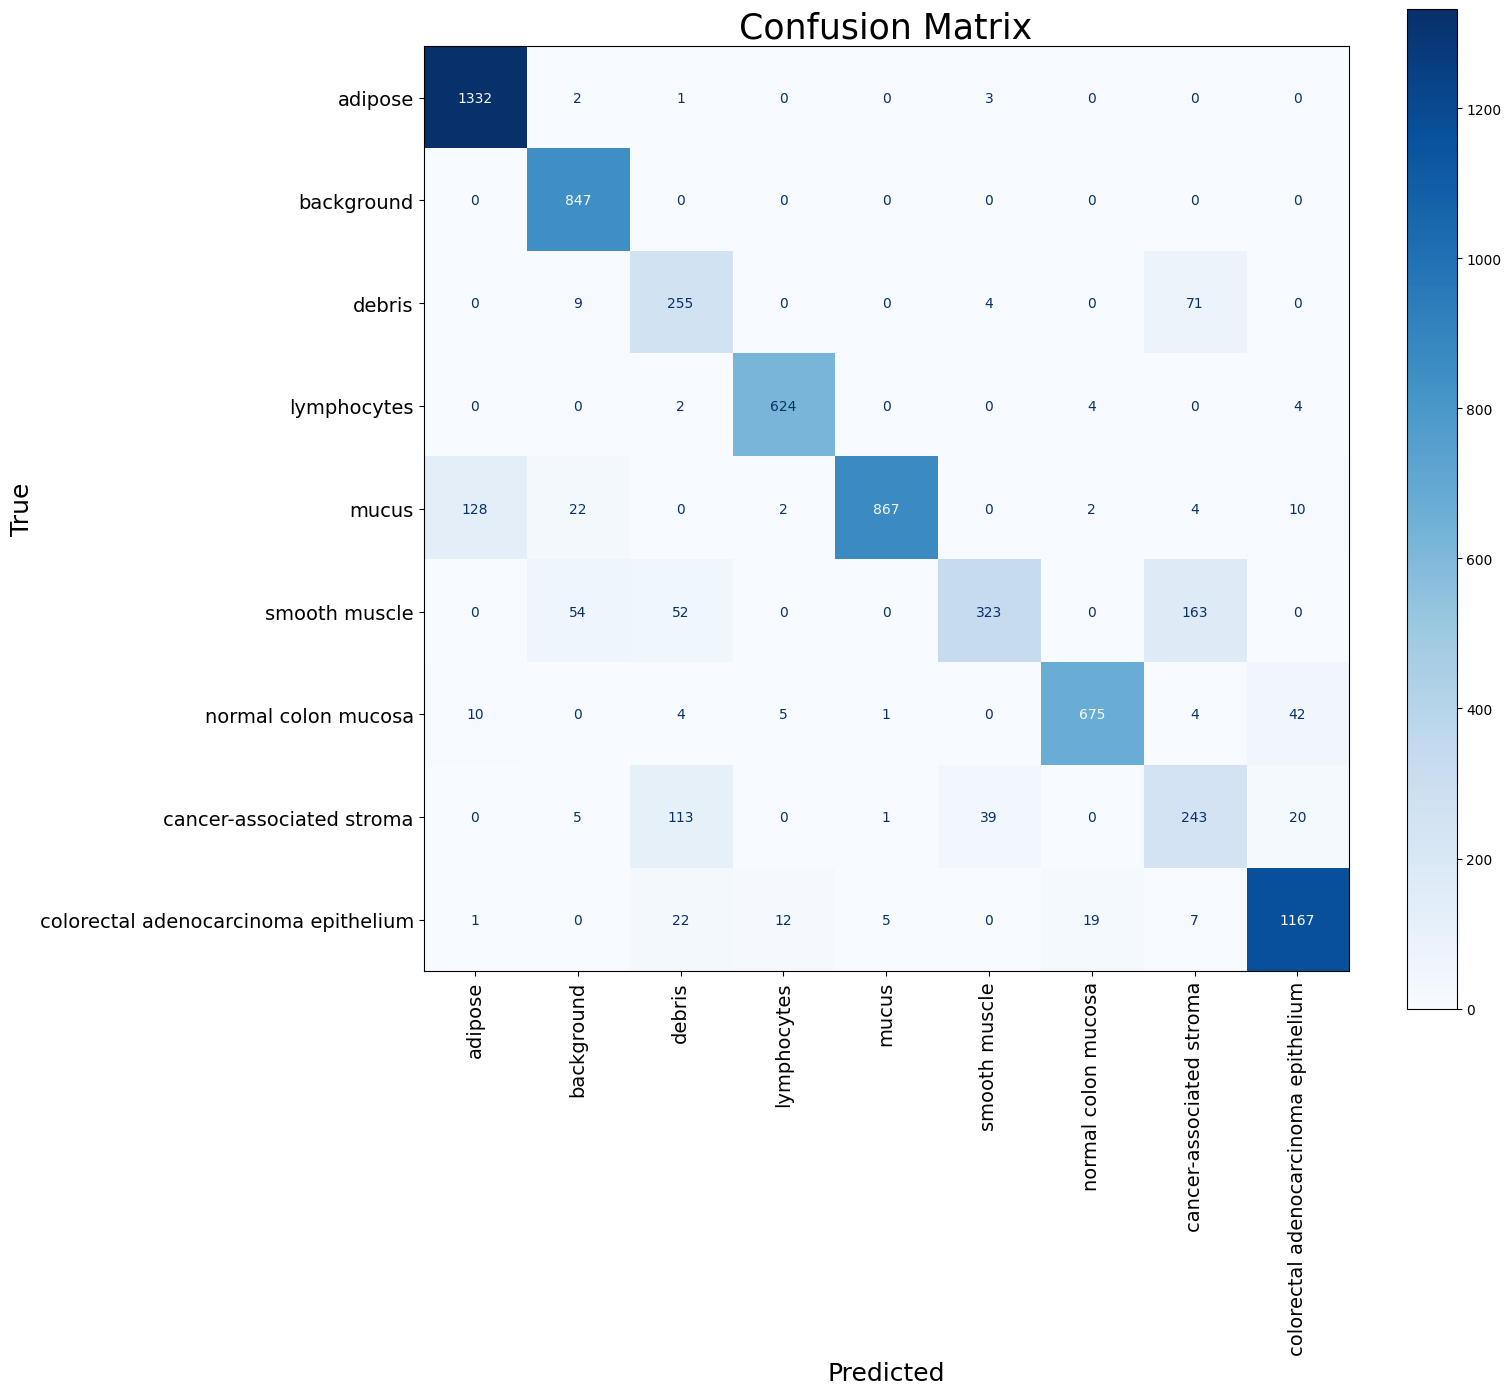

adipose: 0.948
background: 0.948
debris: 0.647
lymphocytes: 0.977
mucus: 0.908
smooth muscle: 0.672
normal colon mucosa: 0.937
cancer-associated stroma: 0.532
colorectal adenocarcinoma epithelium: 0.943


In [86]:
def f1_from_confusion_matrix(cm):
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP

    f1 = 2 * TP / (2 * TP + FP + FN + 1e-8)
    return f1

cm, all_labels, all_preds = plot_confusion_matrix(
    model=cnn_aug,
    data_loader=test_loader,
    title="Confusion Matrix",
    labels_names=labels_names
)

f1_per_class = f1_from_confusion_matrix(cm)
for class_name, f1 in zip(labels_names.values(), f1_per_class):
    print(f"{class_name}: {f1:.3f}")

## Top 3 Most Confused Class Pairs

#### 1. Smooth muscle ↔ Cancer-associated stroma
- Still the most significant confusion (~163 samples)
- Both are stromal tissues with similar elongated and fibrous structures
- The model struggles to distinguish their organization and density patterns

#### 2. Debris ↔ Cancer-associated stroma
- Strong confusion (~113 samples from stroma → debris and 71 from debris → stroma)
- Both exhibit irregular and heterogeneous textures
- The CNN tends to group them as “disorganized tissue” rather than separating biological meaning

#### 3. Mucus ↔ Adipose
- Notable confusion (~128 samples from mucus → adipose)
- Both can appear as light, homogeneous regions with low structural detail
- The model likely relies on intensity/texture rather than true morphological differences

### 7.3 Written Analysis

#### 1. ARCHITECTURE TRADE-OFFS:
MLPs are the simplest baseline — fast to train but lack spatial awareness, making them poor for
image tasks. CNNs exploit local spatial structure through convolutions, which is perfect for
medical imaging where texture and local patterns matter. Transfer learning with ResNet leverages
features pre-learned on millions of images, providing good performance too even with limited
domain-specific data. ViTs capture global dependencies through self-attention but need large
datasets to compensate for lacking the inductive biases of CNNs. For small medical datasets
(< 100k images), CNNs or transfer learning are preferred. ViTs shine with millions of samples.

#### 2. DATA EFFICIENCY:
Transfer learning (ResNet-18) was the most data-efficient, reaching high accuracy quickly because its pretrained weights already encode useful visual features. The ViT was least data-efficient, struggling to learn good representations from scratch with only ~89k 28x28 images. Image resolution was critical: the 28x28 images contain limited detail, which penalizes models that expect high-resolution inputs. Upscaling to 224x224 for ResNet introduced interpolation artifacts but still helped because of pretrained feature compatibility.

#### 3. CLINICAL DEPLOYMENT:
We would deploy the CNN for its best accuracy-speed trade-off. Before clinical use, additional steps are essential: validation on external datasets from different hospitals/scanners, calibration of prediction confidence, integration of uncertainty estimation, prospective clinical trials, and a human-in-the-loop system where the AI assists but doesn't replace pathologists. Edge cases and failure modes must be thoroughly documented.

#### 4. ETHICS:
False negatives are the most dangerous risk, It's why recall metric need to be use. Class imbalance (some tissue types are rarer) can bias the model toward majority classes. Dataset bias from a single institution may not generalize to diverse patient populations. Black-box predictions without interpretability (addressed by Grad-CAM) can erode clinician trust. Transparency in model limitations and clear communication that AI is an assistive tool, not a replacement for expert judgment, is essential.

### Q7.1

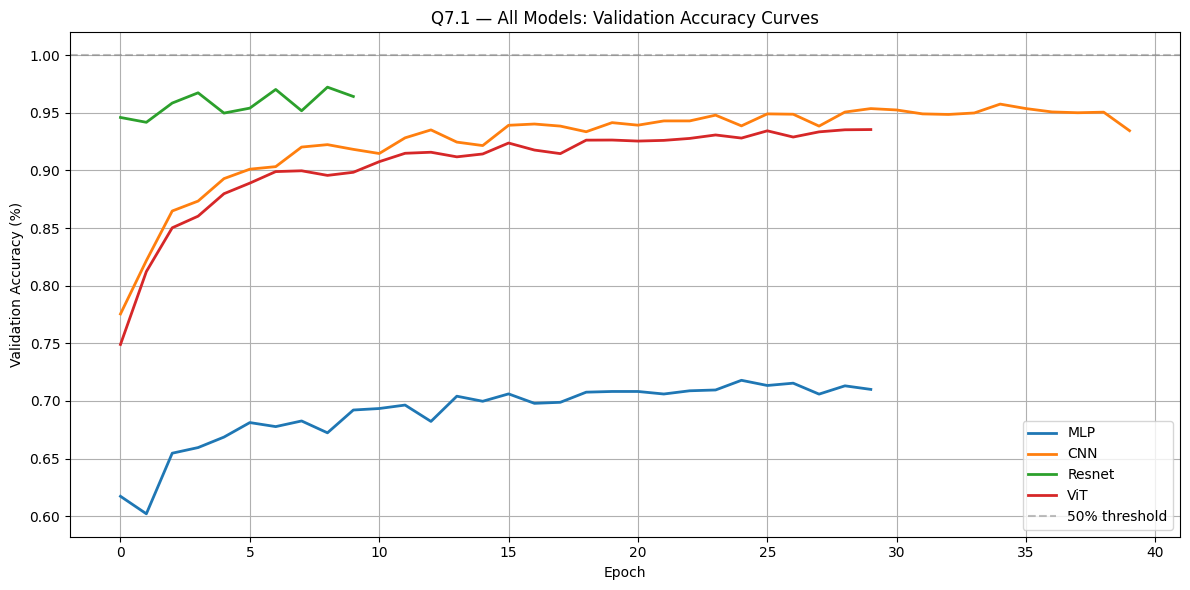

In [87]:
plt.figure(figsize=(12, 6))
plt.plot(history_mlp["val_acc"], linewidth=2, label = 'MLP')
plt.plot(history_cnn_aug["val_acc"], linewidth=2, label = 'CNN')
plt.plot(history_resnet_b["val_acc"], linewidth=2, label = 'Resnet')
plt.plot(history_vit7["val_acc"], linewidth=2, label = 'ViT')
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Q7.1 — All Models: Validation Accuracy Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Q7.2 FeelBack

One unexpected result was that the CNN achieved strong performance despite the very low input resolution (28×28). We initially expected that such small images would not contain enough spatial information for effective feature extraction. However, the model was still able to learn meaningful patterns. We investigated this by analyzing the confusion matrix and Grad-CAM visualizations, which showed that the network focuses on key structural regions even at low resolution.

### Q7.3 Random Label Smoothing

Random label smoothing destroys the correspondence between inputs and targets, turning supervised learning into a noisy or partially unsupervised problem. Instead of regularizing the model, it introduces label noise that biases gradients and prevents the model from converging to meaningful decision boundaries.